In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.ticker import PercentFormatter
from pathlib import Path
from IPython.display import display

ARTIFACTS_TGZ_ROOT = Path("/home/foo")
ARTIFACT_ROOT = ARTIFACTS_TGZ_ROOT / "artifact"
ARTIFACT_MUHYP_ROOT = ARTIFACTS_TGZ_ROOT / "artifact_muhyp"
MODEL_ROOT = ARTIFACT_ROOT / "model"
PLOT_ROOT = ARTIFACTS_TGZ_ROOT / "plot_camera_ready"
PLOT_ROOT.mkdir(exist_ok=True, parents=True)

SMOKE_TEST = True
OLD_NAME = False

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Linux Biolinum"]
plt.rcParams["image.cmap"] = "tab20"

plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font="Linux Biolinum",
    rc=plt.rcParams,
)

plt.rcParams["boxplot.notch"] = False
plt.rcParams["boxplot.vertical"] = False
plt.rcParams["boxplot.whiskers"] = 0.99
plt.rcParams["boxplot.patchartist"] = True
plt.rcParams["boxplot.showfliers"] = False
plt.rcParams["boxplot.medianprops.linewidth"] = 0.75
plt.rcParams["boxplot.medianprops.color"] = "white"
plt.rcParams["boxplot.whiskerprops.linewidth"] = 0.75
plt.rcParams["boxplot.capprops.linewidth"] = 0.75
plt.rcParams["boxplot.boxprops.linewidth"] = 0.5
plt.rcParams["boxplot.showmeans"] = True
plt.rcParams["boxplot.meanprops.marker"] = "o"
plt.rcParams["boxplot.meanprops.markerfacecolor"] = "red"
plt.rcParams["boxplot.meanprops.markeredgecolor"] = "black"
plt.rcParams["boxplot.meanprops.markersize"] = 3

plt.rcParams["axes.edgecolor"] = "0.0"
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True

plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.labelpad"] = 1.0
plt.rcParams["image.cmap"] = "tab20"
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.autolayout"] = True
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.pad_inches"] = 0.0

plt.rcParams["xtick.minor.pad"] = 0.5
plt.rcParams["xtick.major.pad"] = 0.5

figsize_full = (7.0, 2.0)
figsize_half = (3.5, 2.0)
figsize_quarter = (1.65, 1.0)
fig_dpi = 300
font_mini, font_tiny, font_small, font_medium, font_large, font_huge = 5, 6, 8, 10, 12, 14

def fig_quarter():
    plt.rcParams["figure.figsize"] = figsize_quarter
    plt.rcParams["figure.dpi"] = 600
    plt.rcParams["font.size"] = font_mini
    plt.rcParams["axes.titlesize"] = font_mini
    plt.rcParams["axes.labelsize"] = font_tiny
    plt.rcParams["xtick.labelsize"] = font_mini
    plt.rcParams["ytick.labelsize"] = font_mini
    plt.rcParams["legend.fontsize"] = font_mini
    plt.rcParams["figure.titlesize"] = font_small

    for var in ["xtick", "ytick"]:
        plt.rcParams[f"{var}.major.size"] = 3.5 / 2
        plt.rcParams[f"{var}.minor.size"] = 2 / 2
        plt.rcParams[f"{var}.major.width"] = 0.8 / 2
        plt.rcParams[f"{var}.minor.width"] = 0.6 / 2
        plt.rcParams[f"{var}.major.pad"] = 3.5 / 2
        plt.rcParams[f"{var}.minor.pad"] = 3.4 / 2
    plt.rcParams["axes.linewidth"] = 0.8 / 2
    plt.rcParams["grid.linewidth"] = 0.8 / 2
    plt.rcParams["lines.linewidth"] = 2 / 2
    plt.rcParams["lines.markersize"] = 6 / 2

def fig_half():
    plt.rcParams["figure.figsize"] = figsize_half
    plt.rcParams["figure.dpi"] = fig_dpi
    plt.rcParams["font.size"] = font_small
    plt.rcParams["axes.titlesize"] = font_small
    plt.rcParams["axes.labelsize"] = font_small
    plt.rcParams["xtick.labelsize"] = font_small
    plt.rcParams["ytick.labelsize"] = font_small
    plt.rcParams["legend.fontsize"] = font_small
    plt.rcParams["figure.titlesize"] = font_large

    for var in ["xtick", "ytick"]:
        plt.rcParams[f"{var}.major.size"] = 3.5
        plt.rcParams[f"{var}.minor.size"] = 2
        plt.rcParams[f"{var}.major.width"] = 0.8
        plt.rcParams[f"{var}.minor.width"] = 0.6
        plt.rcParams[f"{var}.major.pad"] = 3.5
        plt.rcParams[f"{var}.minor.pad"] = 3.4
    plt.rcParams["axes.linewidth"] = 0.8
    plt.rcParams["grid.linewidth"] = 0.8
    plt.rcParams["lines.linewidth"] = 1
    plt.rcParams["lines.markersize"] = 6

def fig_full():
    plt.rcParams["figure.figsize"] = figsize_full
    plt.rcParams["figure.dpi"] = fig_dpi
    plt.rcParams["font.size"] = font_medium
    plt.rcParams["axes.titlesize"] = font_medium
    plt.rcParams["axes.labelsize"] = font_large
    plt.rcParams["xtick.labelsize"] = font_medium
    plt.rcParams["ytick.labelsize"] = font_medium
    plt.rcParams["legend.fontsize"] = font_medium
    plt.rcParams["figure.titlesize"] = font_huge

def make_legend(handles, labels, path, ncols):
    figLegend = plt.figure()
    plt.figlegend(handles, labels, loc="center", ncols=ncols)
    figLegend.savefig(path)
    plt.close(figLegend)

In [2]:
def read_query_seed_csv(csvf):
    df = pd.read_csv(csvf)
    df = df.drop([0, 1])
    df = df.rename(columns={"Unnamed: 0": "Query", "Unnamed: 1": "Seed"})
    df = df.reset_index(drop=True)
    df = df.sort_values(["Query", "Seed"])
    for col in df.columns:
        if col == "Query":
            df[col] = df[col].astype(str)
        elif col == "Seed":
            try:
                df[col] = df[col].astype(int)
            except:
                df[col] = df[col].astype(str)
        else:
            df[col] = df[col].astype(float)
    return df

def read_runtime_csv(csvf):
    df = pd.read_csv(csvf)
    df = df.rename(columns={"0": "Run-time (ms)"})
    df = df.set_index("Experiment")
    return df

def prettify_time(s):
    min_s = 60
    h_s = 60 * min_s
    day_s = 24 * h_s
    week_s = 7 * day_s
    if s < min_s:
        return f"{s:,.0f}s"
    elif min_s <= s < h_s:
        return f"{s/min_s:,.0f}min"
    elif h_s <= s < day_s or day_s <= s < week_s:
        return f"{s/h_s:,.0f}h"
    # elif day_s <= s < week_s:
    #     return f"{s/day_s:,.0f}d"
    elif week_s <= s:
        return f"{s/week_s:,.0f}w"

In [3]:
def sanity_check():
    import os
    from pathlib import Path
    import pglast

    def sql_file_queries(filepath: Path) -> [str]:
        with open(filepath) as f:
            lines = []
            for line in f:
                if line.startswith("--"):
                    continue
                if len(line.strip()) == 0:
                    continue
                lines.append(line)
            queries = "".join(lines)
            return pglast.split(queries)

    planfiles = sorted(ARTIFACT_ROOT.glob(f"./experiment/**/*.ok"))
    all_ok = True
    for pf in planfiles:
        pfs = str(pf)
        tout = Path(pfs[:-3] + ".timeout")
        res = Path(pfs[:-3] + ".res")
        err = Path(pfs[:-3] + ".err")
        if not (tout.exists() or res.exists() or err.exists()):
            print(pf)
            all_ok = False
    if not all_ok:
        raise Exception
    print(f"OK: {len(planfiles)=}")
    
sanity_check()

OK: len(planfiles)=3471028


In [4]:
extension_name = "boot"
extension_prefix = "Boot"
map_suffix = ""

if OLD_NAME:
    extension_name = "bytejack"
    extension_prefix = "Bytejack"
    map_suffix = "_mmh1"

configs = [
    "default",                                                                # Orig
    f"{extension_name}_e1_iea1_ic1_es0_ss0_ssp100_sss15721",                  # MA
    f"{extension_name}_e1_iea0_ic0_es1_ss0_ssp100_sss15721",                  # µG
    f"{extension_name}_e1_iea1_ic1_es1_ss0_ssp100_sss15721",                  # MA+µG
    f"{extension_name}_e1_iea0_ic0_es0_ss1_ssp50_sss15721",                   # µS
    f"{extension_name}_e1_iea1_ic1_es0_ss1_ssp50_sss15721",                   # MA+µS
    f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp50_sss15721",                   # All
    f"{extension_name}_e1_iea1_ic1_es0_ss0_ssp100_sss15721_mm1{map_suffix}",  # MA.P
    "nts_b10_r15721",                                                         # Automatic
    "sts_b10_r15721",                                                         # Manual
]

rename = {
    "default": "Orig",
    f"{extension_name}_e1_iea1_ic1_es0_ss0_ssp100_sss15721": "MA",
    f"{extension_name}_e1_iea0_ic0_es1_ss0_ssp100_sss15721": "µG",
    f"{extension_name}_e1_iea1_ic1_es1_ss0_ssp100_sss15721": "MA+µG",
    f"{extension_name}_e1_iea0_ic0_es0_ss1_ssp50_sss15721": "µS",
    f"{extension_name}_e1_iea1_ic1_es0_ss1_ssp50_sss15721": "MA+µS",
    f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp50_sss15721": "All",
    f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp10_sss15721": "All-10",
    f"{extension_name}_e1_iea1_ic1_es0_ss0_ssp100_sss15721_mm1{map_suffix}": "MA.P",
    "nts_b10_r15721": "Automatic",
    "sts_b10_r15721": "Manual",
}
rename_inverse = {v: k for k, v in rename.items()}
colors = {c: col for c, col in zip(configs, sns.color_palette("Set2"))}
colors["nts_b10_r15721"] = colors[f"{extension_name}_e1_iea1_ic1_es0_ss0_ssp100_sss15721"]
colors["sts_b10_r15721"] = colors[f"{extension_name}_e1_iea0_ic0_es1_ss0_ssp100_sss15721"]
colors[f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp10_sss15721"] = colors[f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp50_sss15721"]

MAIN_EVAL_CONFIGS = [
    rename_inverse["Orig"],
    rename_inverse["MA"],
    rename_inverse["µG"],
    rename_inverse["MA+µG"],
    rename_inverse["µS"],
    rename_inverse["MA+µS"],
    rename_inverse["All"],
]
ERROR_DISTRIBUTION_CONFIGS = [
    rename_inverse["Orig"],
    rename_inverse["MA"],
    rename_inverse["µG"],
    rename_inverse["µS"],
    rename_inverse["All"],
]
MA_P_CONFIGS = [
    rename_inverse["Orig"],
    rename_inverse["MA"],
    rename_inverse["MA.P"],
]
MU_G_CONFIGS = [
    rename_inverse["Orig"],
    rename_inverse["µG"],
]
SAMPLING_BASELINE_CONFIGS = [
    rename_inverse["Orig"],
    rename_inverse["Automatic"],
    rename_inverse["Manual"],
    rename_inverse["All-10"],
]


def generate_sampling_rate_configs(seeds):
    result = []
    for seed in seeds:
        result.extend([f"{extension_name}_e1_iea1_ic1_es1_ss1_ssp{n}_sss{seed}" for n in range(10,101,10)])
    return result


def macro_accelerated(fp):
    prefix = "{'" + extension_prefix + "': 'true',"
    fp = Path(fp)
    if not fp.exists():
        return False
    with open(fp) as f:
        for line in f:
            return line.startswith(prefix)
    return False

tpch_sf_100-9


,Query Plan Instance,Num Operators,Num Occurrences,Mean Run-time (s)
0,1,18,95,76.252341
1,2,18,25,66.279651
2,3,18,819,65.326872
3,4,18,61,62.122053


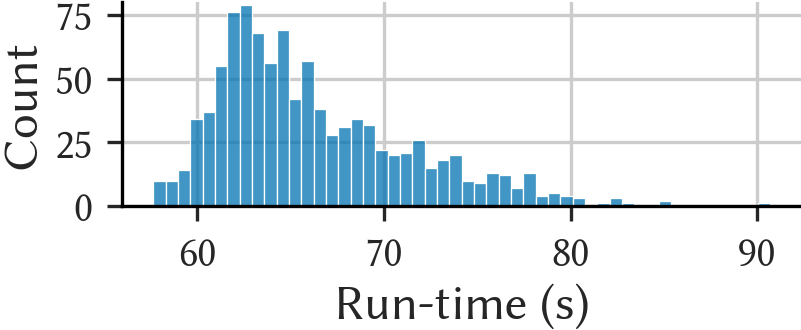

In [5]:
def plot_figure_3():
    def compute_query_hash(fp):
        def _featurize_query_hash(plan_dict):
            node_type = plan_dict["Node Type"]
            output_hash = [node_type]
            if "Plans" in plan_dict:
                for child in plan_dict["Plans"]:
                    output_hash.extend(_featurize_query_hash(child))
            return output_hash

        plan = None
        try:
            with open(fp) as f:
                contents = "".join(f.readlines())
                plan = eval(contents)["Plan"] if len(contents) > 0 else None
        except FileNotFoundError as e:
            if Path(str(fp)[:-len("res")] + "err").exists():
                return None
            raise e
                
        if plan is None:
            return None
        return tuple(_featurize_query_hash(plan))
    
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    expt_name = "tpch_sf_100"
    if SMOKE_TEST:
        expt_name = "tpch_sf_1"
    
    df = pd.read_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
    df["QueryNormalized"] = expt_name + "-" + df["Query"].str.split("-").str[0]
    
    benchmark, *sf = expt_name.split("_")
    sf = "_".join(sf)
    def get_fp(row):
        return str(ARTIFACT_ROOT / f"experiment/default/{benchmark}/{sf}/{row.Seed}/{row.Query}.res")
    
    df["FP"] = df.apply(get_fp, axis=1)
    df["Query Hash"] = df.apply(lambda row: compute_query_hash(row["FP"]), axis=1)

    for pct_n, pct_query in [("example", f"{expt_name}-9")]:
        print(pct_query)
        fig_quarter()
        height = figsize_quarter[1] * 0.7
        width = figsize_quarter[0] * 0.9
        tmpdf = df[df.QueryNormalized == pct_query].copy()
        
        gdata = []
        for gi, (g, gdf) in enumerate(tmpdf.groupby("Query Hash"), 1):
            num_ops = len(g)
            num_occurrences = len(gdf["default"])
            mean_runtime_target = gdf["default"].mean() / 1e3
            gdata.append((gi, num_ops, num_occurrences, mean_runtime_target))
        gdata = pd.DataFrame(gdata, columns=["Query Plan Instance", "Num Operators", "Num Occurrences", f"Mean Run-time (s)"])
        gdata = gdata.sort_values([f"Mean Run-time (s)", "Num Occurrences"], ascending=[False, True])
        display(gdata)
        
        with open(fig_dir / "fig_3a.tex", "w") as f:
            print(r"\begin{tabular}{|r|r|r|r|}", file=f)
            print(r"\hline", file=f)
            print(r"\textbf{Plan Id} & \textbf{Count} & \textbf{Avg Run-time (s)} \\", file=f)
            print(r"\hline", file=f)
            for row in gdata.itertuples():
                _, pid, nops, nocs, mrt = row
                print(f"P{pid} & {nocs} & {mrt:.0f} \\\\", file=f)
            print(r"\hline", file=f)
            print(r"\end{tabular}", file=f)
        
        fig_quarter()
        tmpdf["default (s)"] = tmpdf["default"] / 1e3
        ax = sns.displot(tmpdf, x=f"default (s)", kind="hist", height=height, aspect=width / height, bins=50)
        ax.axes[0][0].set_ylim(top=80)
        ax.axes[0][0].set_yticks([0, 25, 50, 75])
        ax.axes[0][0].set_xlabel(f"Run-time (s)")
        plt.tight_layout()
        plt.savefig(fig_dir / "fig_3b.pdf")
        plt.show()

plot_figure_3()

tpch_sf_10


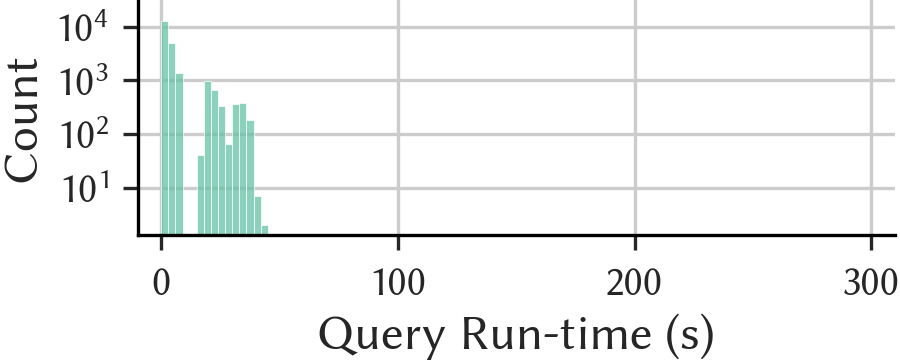

tpch_sf_100


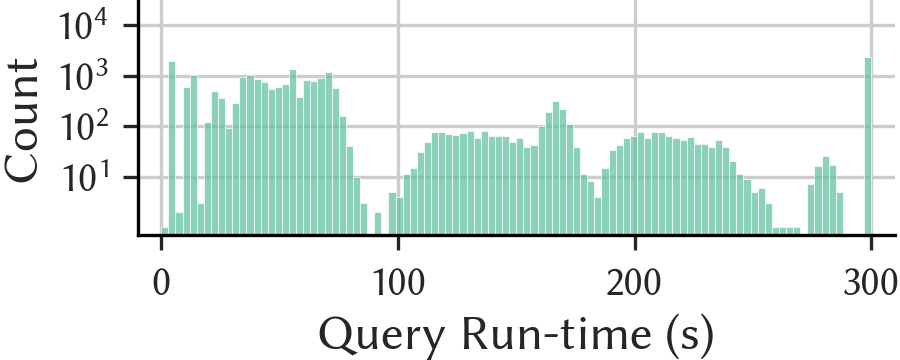

dsb_sf_1


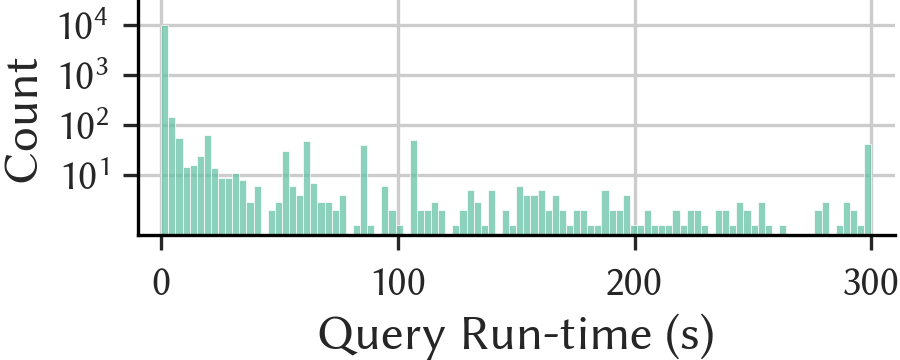

dsb_sf_10


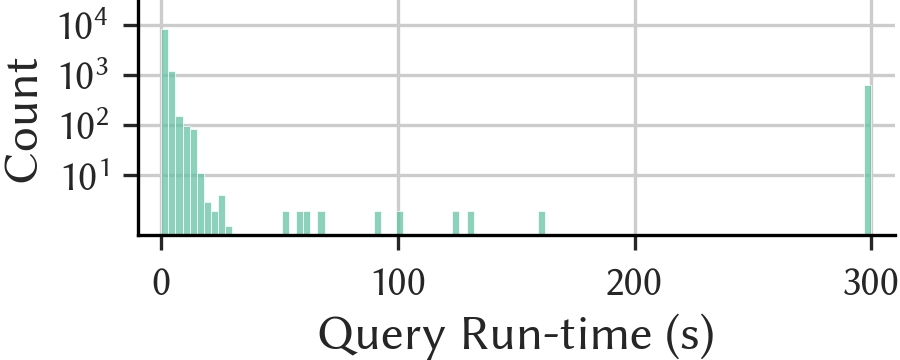

job_sf_none


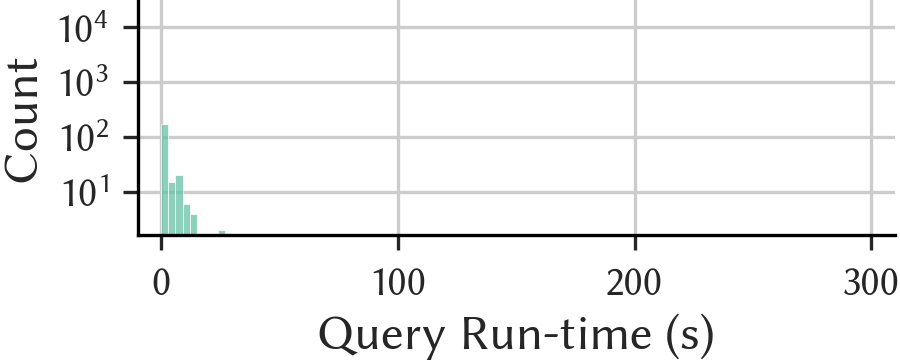

In [6]:
def plot_figure_6():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)
    
    fig_expt = [
        ("fig_6a", "tpch_sf_10"),
        ("fig_6b", "tpch_sf_100"),
        ("fig_6c", "dsb_sf_1"),
        ("fig_6d", "dsb_sf_10"),
        ("fig_6e", "job_sf_none"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("fig_6a", "tpch_sf_1"),
            ("fig_6b", "tpch_sf_1"),
            ("fig_6c", "dsb_sf_1"),
            ("fig_6d", "dsb_sf_1"),
            ("fig_6e", "job_sf_none"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        rqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.75))
        plt.rcParams["xtick.labelsize"] = font_mini - 1
        ax = sns.histplot(rqs_df["default"] / (1e3), bins=100, binrange=(0,300), color=colors["default"])
        ax.set_xlabel("Query Run-time (s)")
        ax.set_yscale("log")
        ax.set_yticks([10**1, 10**2, 10**3, 10**4])
        ax.set_ylim(top=10**(4.5))
        ax.set_xticks([0,100,200,300])
        ax.set_xlim(-10,310)
        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()

plot_figure_6()

tpch_sf_10
Run-time (ms):  [126362008.64600001, 3413789.94, 107078250.649, 2421774.545, 143288863.623, 2569584.7010000004, 2420653.1649999996]
Mean default run-time (ms):  5744.249870260934
std default run-time (ms):  8419.942115353868
Median default run-time (ms):  2388.1855
tpch_sf_10 names and runtimes
['Orig', 'MA', 'µG', 'MA+µG', 'µS', 'MA+µS', 'All']
[126362.00864600002, 3413.78994, 107078.25064900001, 2421.7745449999998, 143288.86362299998, 2569.584701, 2420.6531649999997]
Orig  speedup (x): 1.0
MA  speedup (x): 37.015168146520466
µG  speedup (x): 1.180090334686282
MA+µG  speedup (x): 52.17744521548765
µS  speedup (x): 0.8818690123641754
MA+µS  speedup (x): 49.176043349271175
All  speedup (x): 52.20161668472651


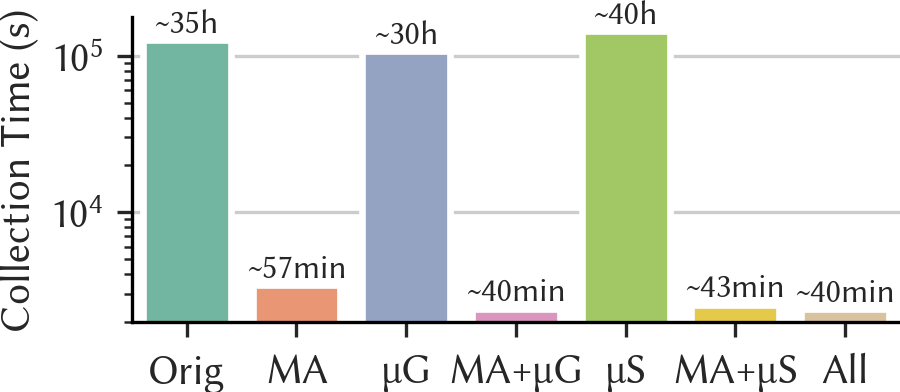

tpch_sf_100
Run-time (ms):  [1929170683.861, 929967021.419, 948211973.2989998, 316953667.74399996, 1764915664.352, 619182775.7459999, 300300465.67300004]
Mean default run-time (ms):  87697.54904359487
std default run-time (ms):  89268.93718612051
Median default run-time (ms):  55132.1485
tpch_sf_100 names and runtimes
['Orig', 'MA', 'µG', 'MA+µG', 'µS', 'MA+µS', 'All']
[1929170.683861, 929967.021419, 948211.9732989998, 316953.667744, 1764915.664352, 619182.7757459999, 300300.465673]
Orig  speedup (x): 1.0
MA  speedup (x): 2.074450641182259
µG  speedup (x): 2.0345352496964035
MA+µG  speedup (x): 6.0866015452427895
µS  speedup (x): 1.093066780938401
MA+µS  speedup (x): 3.11567239824575
All  speedup (x): 6.424134839543313


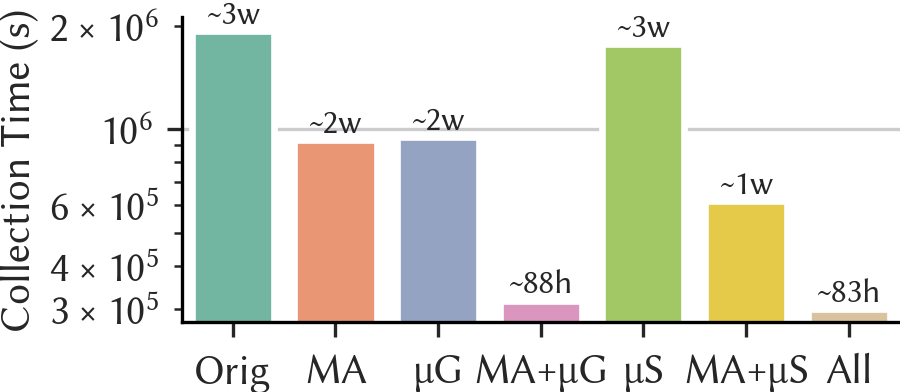

dsb_sf_1
Run-time (ms):  [58546157.383, 4200017.587, 2885347.56, 334142.593, 19148848.013000004, 2900040.8610000005, 378273.735]
Mean default run-time (ms):  5524.264708718626
std default run-time (ms):  29893.00042414444
Median default run-time (ms):  134.58100000000002
dsb_sf_1 names and runtimes
['Orig', 'MA', 'µG', 'MA+µG', 'µS', 'MA+µS', 'All']
[58546.157383, 4200.017587, 2885.34756, 334.142593, 19148.848013000003, 2900.0408610000004, 378.273735]
Orig  speedup (x): 1.0
MA  speedup (x): 13.939502911657687
µG  speedup (x): 20.2908509860767
MA+µG  speedup (x): 175.21309348012392
µS  speedup (x): 3.0574245167779006
MA+µS  speedup (x): 20.188045682505294
All  speedup (x): 154.77193356551703


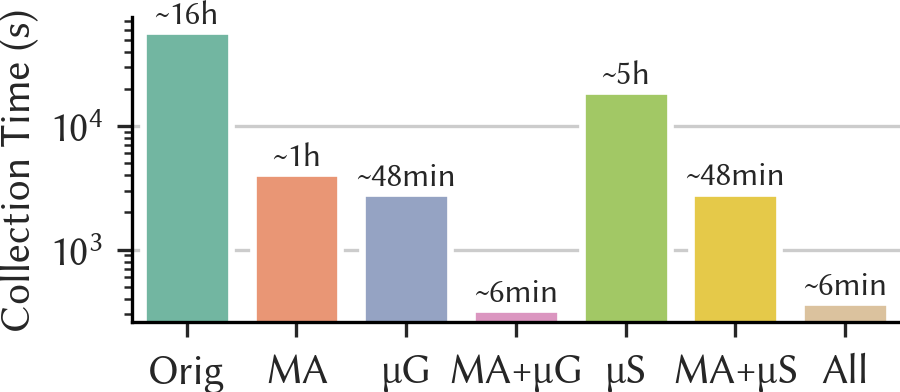

dsb_sf_10
Run-time (ms):  [205282096.578, 65237368.373, 8824766.927000001, 907663.9780000001, 98131461.223, 44597952.235, 765942.304]
Mean default run-time (ms):  19373.546298414498
std default run-time (ms):  70473.77616072673
Median default run-time (ms):  864.9405
dsb_sf_10 names and runtimes
['Orig', 'MA', 'µG', 'MA+µG', 'µS', 'MA+µS', 'All']
[205282.096578, 65237.368373000005, 8824.766927, 907.6639780000002, 98131.461223, 44597.952235, 765.942304]
Orig  speedup (x): 1.0
MA  speedup (x): 3.146694934171513
µG  speedup (x): 23.262041737320548
MA+µG  speedup (x): 226.1653007650811
µS  speedup (x): 2.091909098464398
MA+µS  speedup (x): 4.602948931294132
All  speedup (x): 268.01248019067503


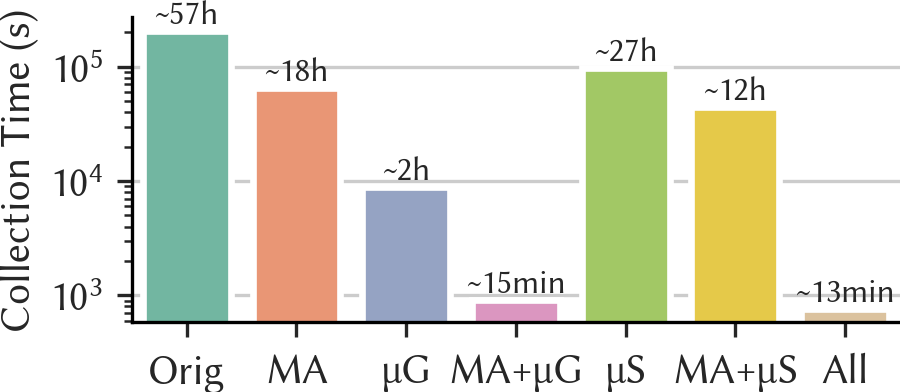

job_sf_none
Run-time (ms):  [473697.961, 427315.292, 456306.12200000003, 403039.271, 106631.606, 92440.462, 98214.398]
Mean default run-time (ms):  2163.004388127854
std default run-time (ms):  3727.616154391137
Median default run-time (ms):  488.551
job_sf_none names and runtimes
['Orig', 'MA', 'µG', 'MA+µG', 'µS', 'MA+µS', 'All']
[473.697961, 427.315292, 456.306122, 403.039271, 106.631606, 92.440462, 98.214398]
Orig  speedup (x): 1.0
MA  speedup (x): 1.108544369622045
µG  speedup (x): 1.0381144108340497
MA+µG  speedup (x): 1.175314653147038
µS  speedup (x): 4.4423785664449245
MA+µS  speedup (x): 5.124357351221374
All  speedup (x): 4.823100997880168


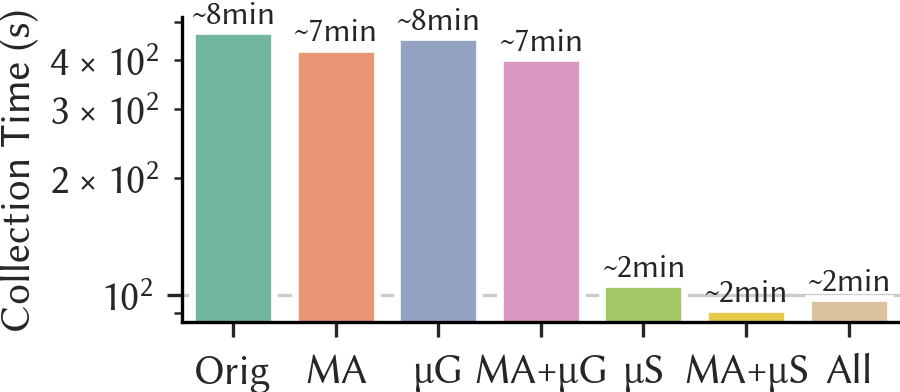

In [7]:
def plot_figure_7():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MAIN_EVAL_CONFIGS
    palette = [colors[c] for c in configs]
    names = [rename[c] for c in configs]
    xticklabels = [str(x) for x in names]

    fig_expt = [
        ("fig_7a", "tpch_sf_10"),
        ("fig_7b", "tpch_sf_100"),
        ("fig_7c", "dsb_sf_1"),
        ("fig_7d", "dsb_sf_10"),
        ("fig_7e", "job_sf_none"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("fig_7a", "tpch_sf_1"),
            ("fig_7b", "tpch_sf_1"),
            ("fig_7c", "dsb_sf_1"),
            ("fig_7d", "dsb_sf_1"),
            ("fig_7e", "job_sf_none"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        rqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        runtimes_ms = [rqs_df[c].sum() for c in configs]
        runtimes_readable = [prettify_time(x/1000) for x in runtimes_ms]

        print("Run-time (ms): ", runtimes_ms)
        print("Mean default run-time (ms): ", rqs_df["default"].mean())
        print("std default run-time (ms): ", rqs_df["default"].std())
        print("Median default run-time (ms): ", rqs_df["default"].median())

        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.8))
        plt.rcParams["xtick.labelsize"] = font_mini - 1
        runtimes_s = [x / 1000 for x in runtimes_ms]
        print(f"{expt_name} names and runtimes")
        print(names)
        print(runtimes_s)
        for name, runtime in zip(names, runtimes_s):
            print(name, " speedup (x):", runtimes_s[0] / runtime)
        ax = sns.barplot(x=names, y=runtimes_s, hue=names, palette=palette, dodge=False, ax=ax)
        runtimes_labels = [f"~{b}" for a, b in zip(runtimes_s, runtimes_readable)]
        for container, label in zip(ax.containers, runtimes_labels):
            ax.bar_label(container, fmt=label, padding=0, fontsize=font_mini - 1)
        ax.set_yscale("log")
        ax.set_ylabel("Collection Time (s)", fontsize=font_tiny - 1)

        patches = []
        patches_labels = []
        for c in configs:
            label = rename[c]
            if label == "MA":
                label = "MA (Macro)"
            elif label == "µG":
                label = "µG (Micro, Gate)"
            elif label == "µS":
                label = "µG (Micro, Sampler)"
            patch = mpl.patches.Patch(color=colors[c], label=label)
            patches.append(patch)
            patches_labels.append(label)

        if fig_name == "fig_7a":
            figLegend = plt.figure()
            plt.figlegend(patches, patches_labels, loc="center", ncols=len(patches_labels))
            figLegend.savefig(fig_dir / f"fig_7_legend.pdf")
            plt.close(figLegend)

        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()
    
plot_figure_7()

tpch_sf_10


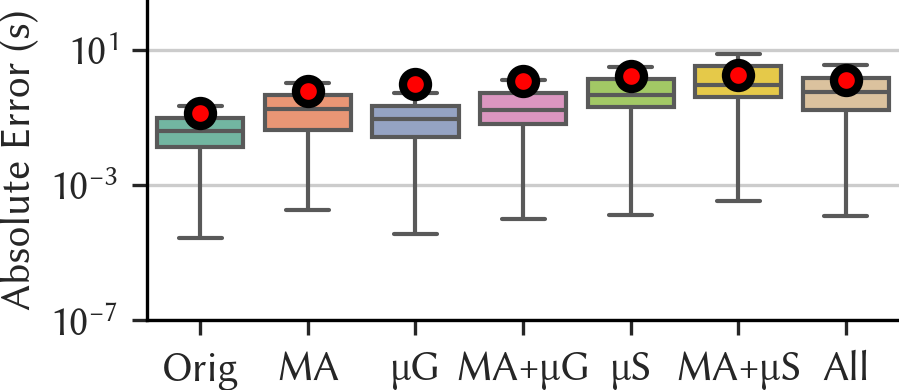

tpch_sf_100


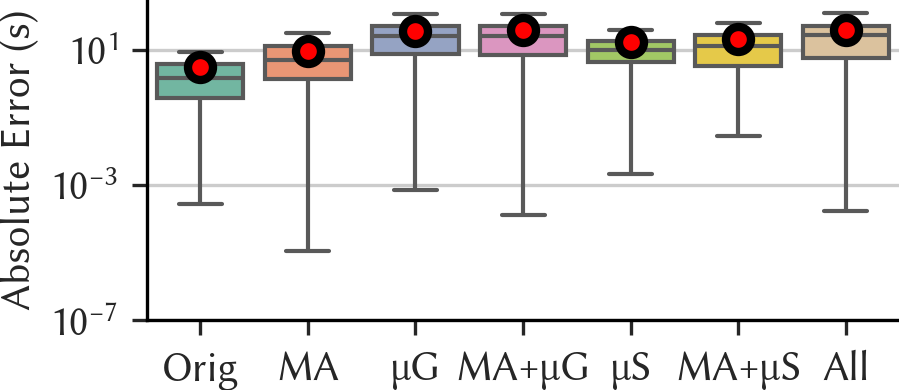

dsb_sf_1


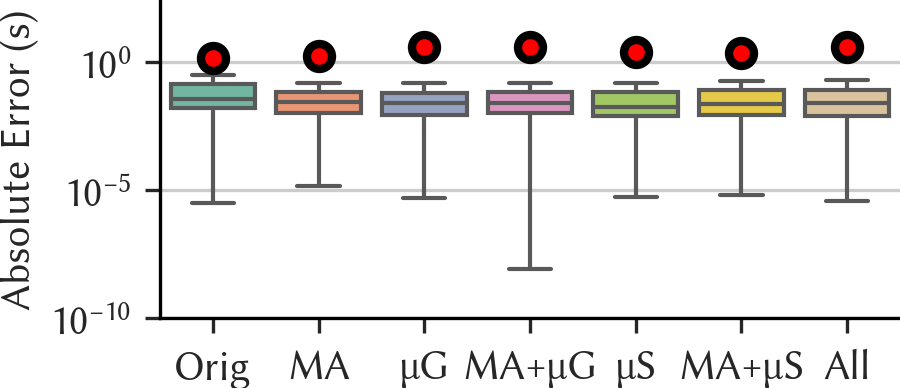

dsb_sf_10


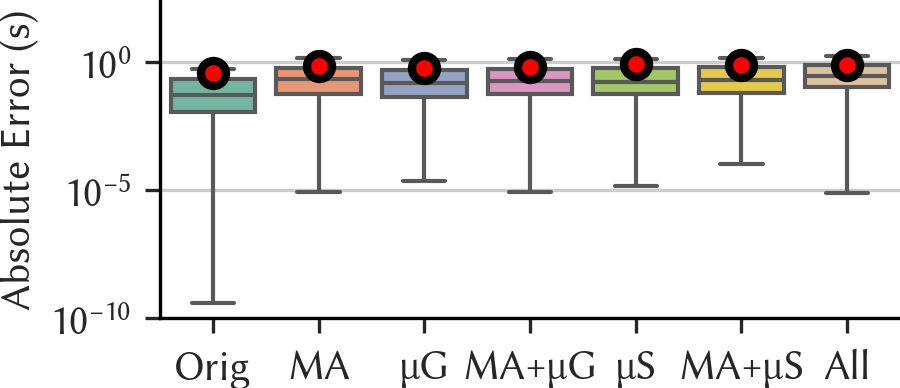

job_sf_none


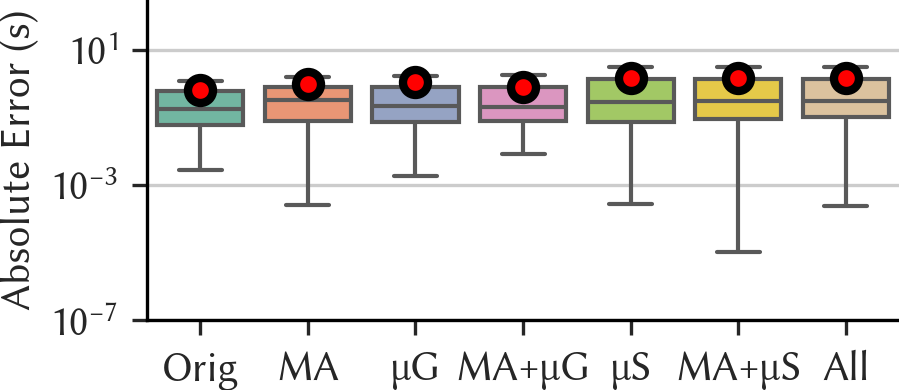

In [8]:
def plot_figure_8():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MAIN_EVAL_CONFIGS
    palette = [colors[c] for c in configs]
    names = [rename[c] for c in configs]
    xticklabels = [str(x) for x in names]

    fig_expt = [
        ("fig_8a", "tpch_sf_10"),
        ("fig_8b", "tpch_sf_100"),
        ("fig_8c", "dsb_sf_1"),
        ("fig_8d", "dsb_sf_10"),
        ("fig_8e", "job_sf_none"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("fig_8a", "tpch_sf_1"),
            ("fig_8b", "tpch_sf_1"),
            ("fig_8c", "dsb_sf_1"),
            ("fig_8d", "dsb_sf_1"),
            ("fig_8e", "job_sf_none"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        eqs_df = pd.read_csv(MODEL_ROOT / f"{expt_name}/error_query_seed.csv")

        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.8))
        plt.rcParams["xtick.labelsize"] = font_mini - 1
        ax = sns.boxplot(eqs_df[configs], showfliers=False, palette=palette, linewidth=0.5, showmeans=True, ax=ax)
        ax.set_yscale("log")
        if expt_name == "dsb_sf_1" or expt_name == "dsb_sf_10":
            ax.set_ylim(bottom=10**-10, top=300)
        else:
            ax.set_ylim(bottom=10**-7, top=300)
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(xticklabels)
        ax.set_ylabel("Absolute Error (s)", fontsize=font_tiny - 1)
        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()
    
plot_figure_8()

In [9]:
def plot_table_3():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MAIN_EVAL_CONFIGS
    names = [rename[c] for c in configs]
    
    fig_expt = [
        ("table_3a", "tpch_sf_10"),
        ("table_3b", "tpch_sf_100"),
        ("table_3c", "dsb_sf_1"),
        ("table_3d", "dsb_sf_10"),
        ("table_3e", "job_sf_none"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("table_3a", "tpch_sf_1"),
            ("table_3b", "tpch_sf_1"),
            ("table_3c", "dsb_sf_1"),
            ("table_3d", "dsb_sf_1"),
            ("table_3e", "job_sf_none"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        pqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/prediction_query_seed.csv")
        factor_errors = {}
        for c in configs:
            a = pqs_df["Operator Time"].clip(lower=1e-3).div(pqs_df[f"Predicted_{c}"].clip(lower=1e-3), axis=0)
            b = pqs_df["Operator Time"].clip(lower=1e-3).rdiv(pqs_df[f"Predicted_{c}"].clip(lower=1e-3), axis=0)
            factor_errors[c] = pd.concat([a,b]).groupby(level=0).max()
        factor_errors = pd.DataFrame(factor_errors)

        factor_errors_table = {}
        cutoff1 = 1.1
        cutoff2 = 2
        cutoff3 = 5

        for c in configs:
            factor_errors_table[c] = [
                (factor_errors[c] <= cutoff1).mean(),
                ((cutoff1 < factor_errors[c]) & (factor_errors[c] < cutoff2)).mean(),
                ((cutoff2 < factor_errors[c]) & (factor_errors[c] < cutoff3)).mean(),
                (factor_errors[c] >= cutoff3).mean(),
            ]
        factor_errors_table = pd.DataFrame(factor_errors_table).T
        factor_errors_table.columns = [
            f"R <= {cutoff1}",
            f"{cutoff1} < R < {cutoff2}",
            f"{cutoff2} < R < {cutoff3}",
            f"R >= {cutoff3}",
        ]
        factor_errors_table = (factor_errors_table * 100).round(0).astype(int)
        factor_errors_table.index = names
        display(factor_errors_table)

        with open(fig_dir / f"{fig_name}.tex", "w") as f:
            print(r"\begin{tabular}{|r|rrrr|}", file=f)
            print(r"\hline", file=f)
            print(r" & \multicolumn{4}{c|}{\textbf{Factor Error}} \\", file=f)
            print(f"& {cutoff1} $\le$ & [{cutoff1},{cutoff2}] & [{cutoff2},{cutoff3}] & $\ge$ {cutoff3} \\\\", file=f)
            print(r"\hline", file=f)
            for row in factor_errors_table.itertuples():
                print(r"{} & {}\% & {}\% & {}\% & {}\% \\".format(*[r"\textbf{" + x + r"}" if i == 0 else x for i, x in enumerate(row)]), file=f)
            print(r"\hline", file=f)
            print(r"\end{tabular}", file=f)

plot_table_3()

tpch_sf_10


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,94,6,0,0
MA,50,50,0,0
µG,82,18,0,0
MA+µG,43,55,1,0
µS,25,52,22,0
MA+µS,4,60,33,3
All,22,49,28,1


tpch_sf_100


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,82,18,0,0
MA,44,51,6,0
µG,10,38,33,19
MA+µG,9,33,37,21
µS,18,69,14,0
MA+µS,11,69,20,0
All,4,41,30,25


dsb_sf_1


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,18,45,18,19
MA,16,61,17,6
µG,15,64,13,8
MA+µG,16,57,17,11
µS,21,59,15,5
MA+µS,18,57,16,9
All,17,57,15,10


dsb_sf_10


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,52,42,4,1
MA,14,64,17,4
µG,18,71,10,2
MA+µG,15,64,16,4
µS,15,63,19,3
MA+µS,15,59,21,5
All,6,53,35,7


job_sf_none


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,4,63,21,12
MA,5,36,39,19
µG,5,35,44,16
MA+µG,6,55,24,15
µS,3,6,12,80
MA+µS,1,3,4,93
All,1,0,1,98


tpch_sf_100 Orig fig_9a


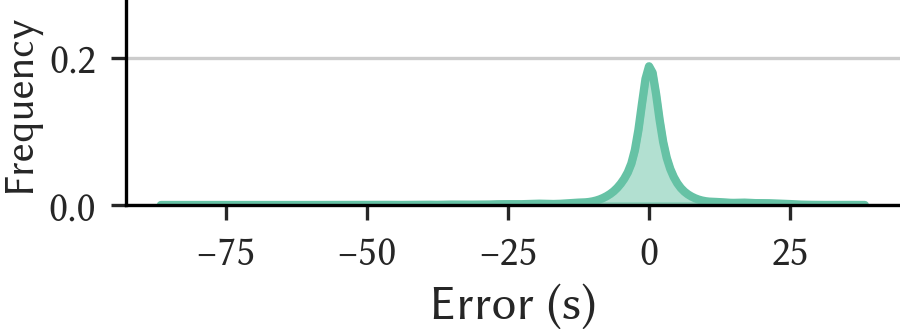

tpch_sf_100 MA fig_9d


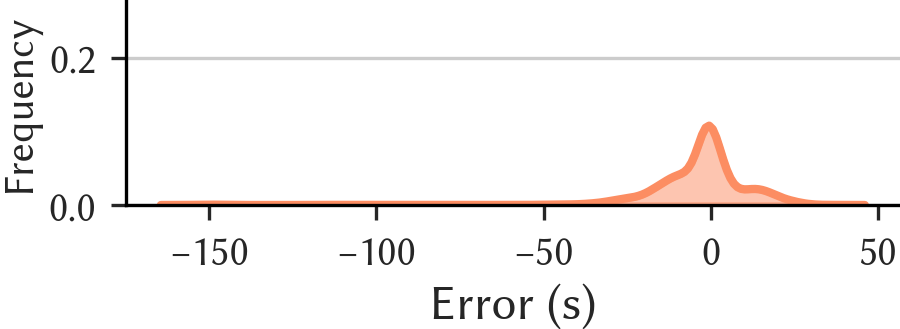

tpch_sf_100 µG fig_9g


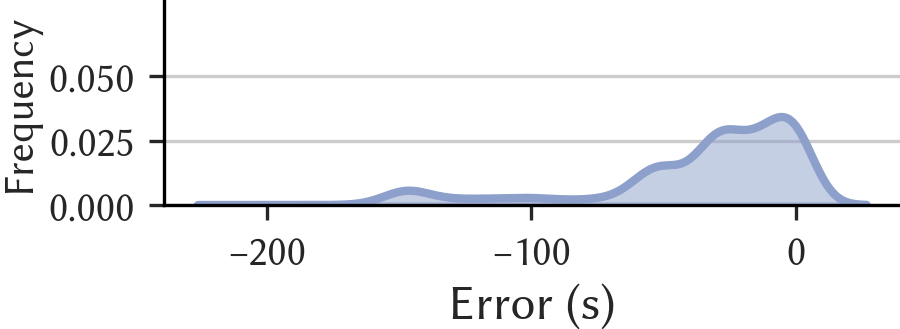

tpch_sf_100 µS fig_9j


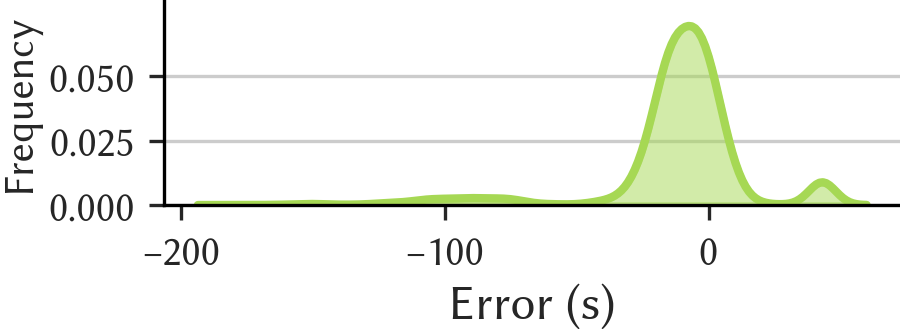

tpch_sf_100 All fig_9m


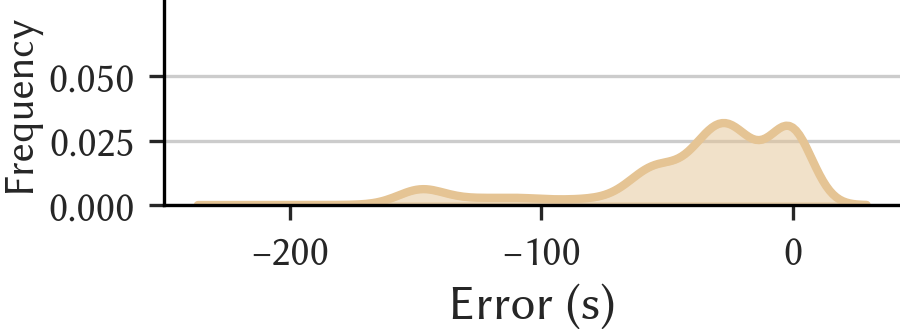

dsb_sf_10 Orig fig_9b


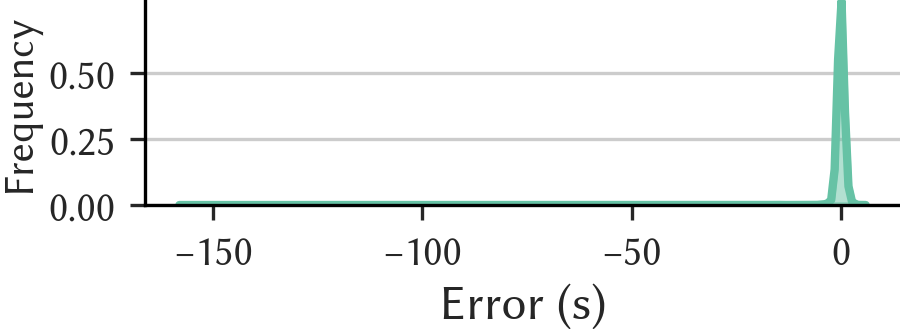

dsb_sf_10 MA fig_9e


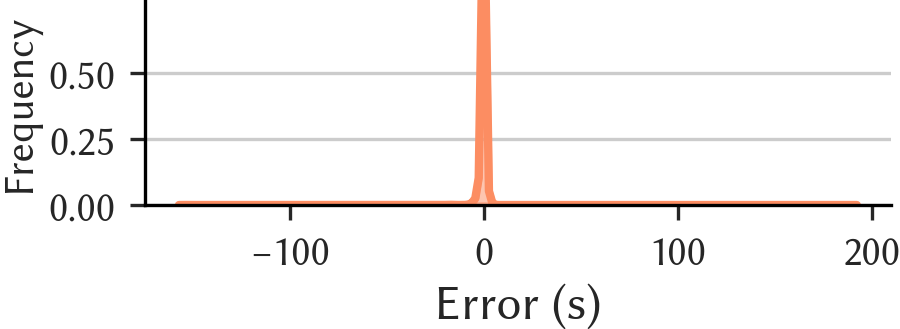

dsb_sf_10 µG fig_9h


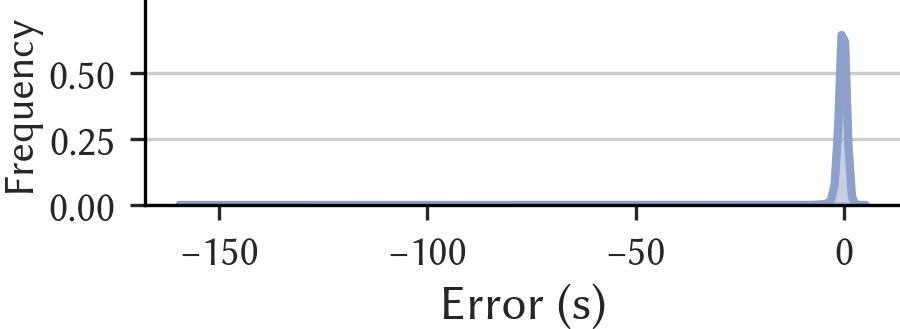

dsb_sf_10 µS fig_9k


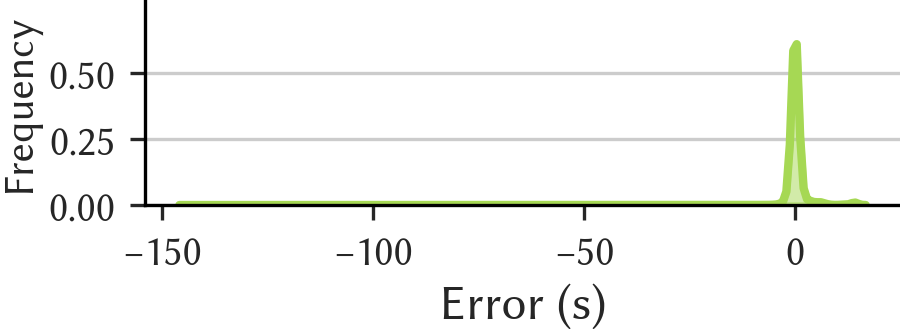

dsb_sf_10 All fig_9n


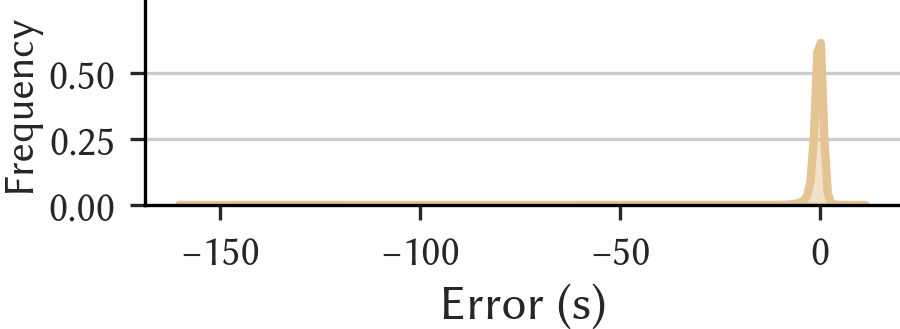

job_sf_none Orig fig_9c


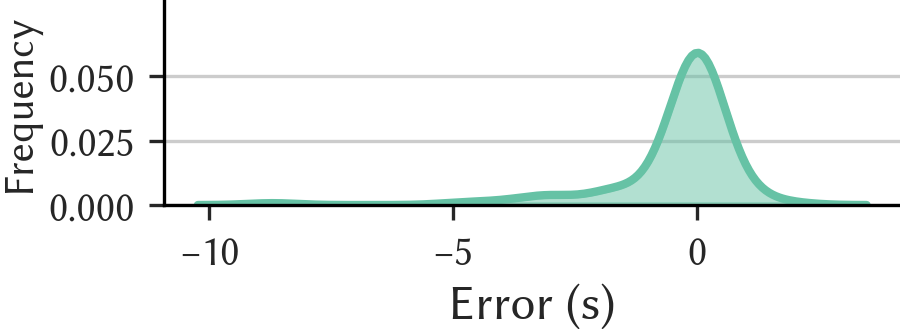

job_sf_none MA fig_9f


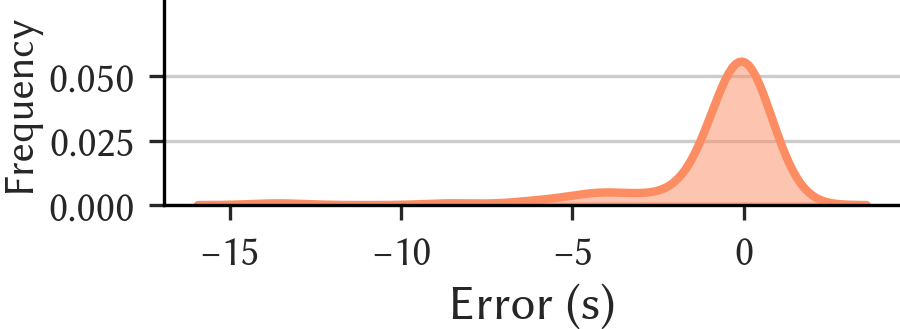

job_sf_none µG fig_9i


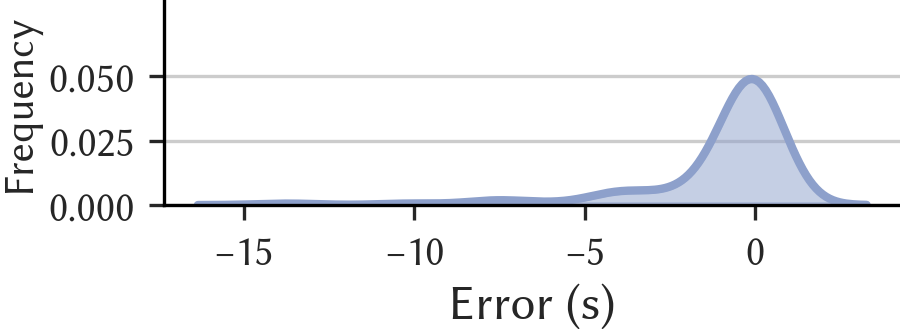

job_sf_none µS fig_9l


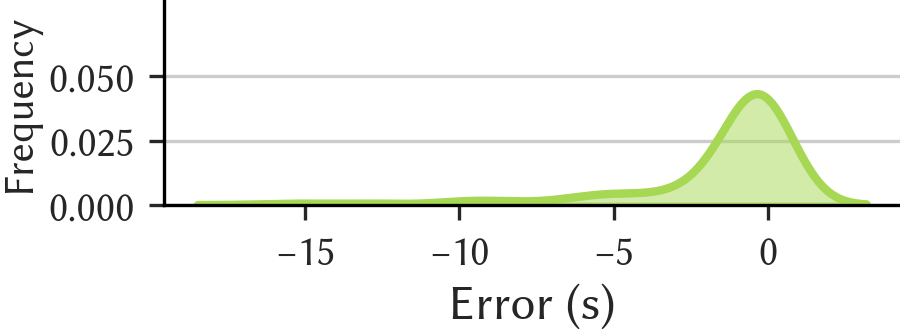

job_sf_none All fig_9o


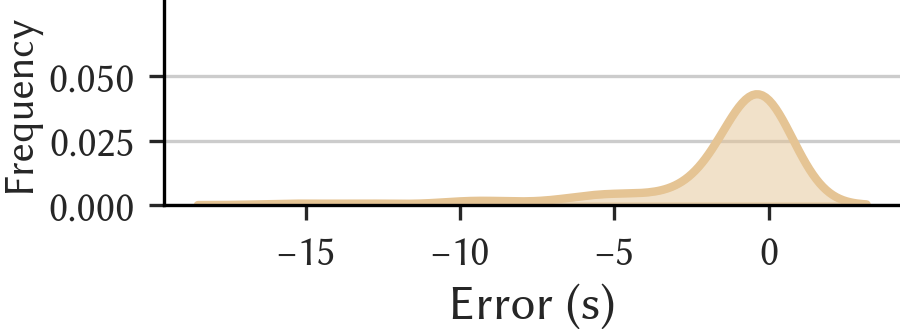

In [10]:
def plot_figure_9():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = ERROR_DISTRIBUTION_CONFIGS
    names = [rename[c] for c in configs]
    
    expt = [
        "tpch_sf_100",
        "dsb_sf_10",
        "job_sf_none",
    ]
    if SMOKE_TEST:
        expt = [
            "tpch_sf_1",
            "dsb_sf_1",
            "job_sf_none",
        ]
    
    for i, expt_name in enumerate(expt):
        pqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/prediction_query_seed.csv")
        for j, c in enumerate(configs):
            fig_letter = chr(ord("a") + i + j * 3)
            fig_name = f"fig_9{fig_letter}"
            print(expt_name, rename[c], fig_name)
            errors = pqs_df[f"Predicted_{c}"] - pqs_df["Operator Time"]
            fig_quarter()
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.7))
            ax = sns.histplot(data=errors, color=colors[c], stat="proportion", bins=100, kde=True, kde_kws={"cut": 3})
            ax.containers[0].remove()
            ax.relim()
            ax.autoscale_view()
            ax.set_ylabel("Frequency", fontsize=font_tiny - 1)
            ax.set_xlabel("Error (s)")
            if "tpch_sf_100" == expt_name:
                if rename[c] in ["Orig", "MA"]:
                    ax.set_ylim(top=0.28)
                else:
                    ax.set_ylim(top=0.08)
                    ax.set_yticks([0,0.025,0.05])
            elif "dsb_sf_10" == expt_name:
                ax.set_ylim(top=0.78)
                ax.set_yticks([0,0.25,0.5])
            elif "job_sf_none" == expt_name:
                ax.set_ylim(top=0.08)
                ax.set_yticks([0,0.025,0.05])
            line = ax.lines[0]
            ax.fill_between(line.get_xdata(), line.get_ydata(), color=colors[c], alpha=0.5)
            ax.grid(axis="x")
            plt.tight_layout()
            plt.savefig(fig_dir / f"{fig_name}.pdf")
            plt.show()

plot_figure_9()

tpch_sf_100 fig_10a


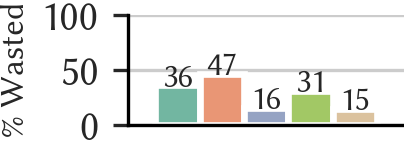

dsb_sf_1 fig_10b


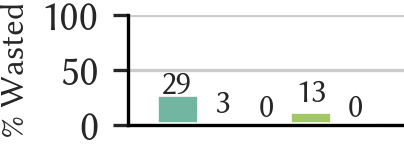

dsb_sf_10 fig_10c


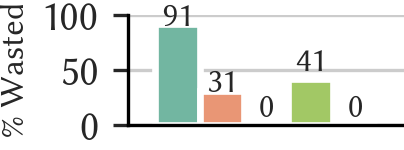

In [11]:
def plot_figure_10():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = ERROR_DISTRIBUTION_CONFIGS
    names = [rename[c] for c in configs]
    for c in configs:
        colors[rename[c] if c in rename else c] = colors[c]
    
    timeouts = []
    for expt_name in configs:
        for benchmark in ["tpch", "dsb"]:
            sfs = [1,10] if benchmark == "dsb" else [10,100]
            for sf in sfs:
                for fp in Path(ARTIFACT_ROOT / f"experiment/{expt_name}/{benchmark}/sf_{sf}/").glob("**/*.timeout"):
                    query = fp.stem
                    seed = fp.parent.name
                    config = ("DSB" if benchmark == "dsb" else "TPC-H") + f" (SF {sf})"
                    timeouts.append((expt_name, config, benchmark, sf, seed, query, fp))
    timeouts = pd.DataFrame(timeouts, columns=["Experiment", "Config", "Benchmark", "SF", "Seed", "Query", "FP"])
    timeouts = timeouts.groupby(["Experiment", "Config"])["FP"].count().reset_index()
    timeouts["Time (hr)"] = timeouts["FP"] * 300 / (60 * 60)
    timeouts["Experiment"] = timeouts["Experiment"].map(rename)

    adders = []
    for a in timeouts.Experiment.unique():
        for b in timeouts.Config.unique():
            in_timeouts = len(timeouts[(timeouts.Experiment == a) & (timeouts.Config == b)]) > 0
            if not in_timeouts:
                adders.append((a,b))
    for (a, b) in adders:
        timeouts.loc[len(timeouts)] = [a, b, 0, 0]
    
    legacy_expt = [
        ("tpch10", "tpch_sf_10"),
        ("tpch100", "tpch_sf_100"),
        ("dsb1", "dsb_sf_1"),
        ("dsb10", "dsb_sf_10"),
    ]
    if SMOKE_TEST:
        legacy_expt = [
            ("dsb1", "dsb_sf_1"),
        ]

    for legacy_label, expt_name in legacy_expt:
        rqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        runtime_ms = rqs_df[rename_inverse["Orig"]].sum()
        timeouts[f"{legacy_label}raw"] = runtime_ms / (1000 * 60 * 60)

    if SMOKE_TEST:
        timeouts["dsb1norm"] = timeouts["Time (hr)"] / timeouts["dsb1raw"] * 100
    else:
        timeouts["tpch10norm"] = timeouts["Time (hr)"] / timeouts["tpch10raw"] * 100
        timeouts["tpch100norm"] = timeouts["Time (hr)"] / timeouts["tpch100raw"] * 100
        timeouts["dsb1norm"] = timeouts["Time (hr)"] / timeouts["dsb1raw"] * 100
        timeouts["dsb10norm"] = timeouts["Time (hr)"] / timeouts["dsb10raw"] * 100    

    if SMOKE_TEST:
        print("Skipping fig_10a for smoke test.")
    else:
        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0] / 2, .4))
        ax = sns.barplot(data=timeouts[timeouts.Config == "TPC-H (SF 100)"], x="Config", y="tpch100norm", hue="Experiment", hue_order=names, palette=colors, ax=ax)
        for container in ax.containers:
            ax.bar_label(container, fmt="%.0f", padding=-1.1, fontsize=4)
        ax.set_yticks([0, 50, 100])
        ax.set_xlabel("")
        ax.set(xticklabels=[])
        ax.set_ylabel("% Wasted", fontsize=4)
        ax.tick_params(bottom=False)
        h, l = ax.get_legend_handles_labels()
        make_legend(h, l, fig_dir / f"fig_10_legend.pdf", len(names))
        ax.legend_.remove()
        fig_name = "fig_10a"
        print("tpch_sf_100", fig_name)
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()

    fig_quarter()
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0] / 2, .4))
    ax = sns.barplot(data=timeouts[timeouts.Config == "DSB (SF 1)"], x="Config", y="dsb1norm", hue="Experiment", hue_order=names, palette=colors, ax=ax)
    for i, container in enumerate(ax.containers):
        ax.bar_label(container, fmt="%.0f", padding=-1.1 if i <= 0 else 0, fontsize=4)
    ax.set_yticks([0, 50, 100])
    ax.set_xlabel("")
    ax.set(xticklabels=[])
    ax.set_ylabel("% Wasted", fontsize=4)
    ax.tick_params(bottom=False)
    ax.legend_.remove()
    fig_name = "fig_10b"
    print("dsb_sf_1", fig_name)
    plt.savefig(fig_dir / f"{fig_name}.pdf")
    plt.show()

    if SMOKE_TEST:
        print("Skipping fig_10c for smoke test.")
    else:
        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0] / 2, .4))
        ax = sns.barplot(data=timeouts[timeouts.Config == "DSB (SF 10)"], x="Config", y="dsb10norm", hue="Experiment", hue_order=names, palette=colors, ax=ax)
        for i, container in enumerate(ax.containers):
            ax.bar_label(container, fmt="%.0f", padding=-1.1 if i <= 1 else 0, fontsize=4)
        ax.set_yticks([0, 50, 100])
        ax.set_xlabel("")
        ax.set(xticklabels=[])
        ax.set_ylabel("% Wasted", fontsize=4)
        ax.tick_params(bottom=False)
        ax.legend_.remove()
        fig_name = "fig_10c"
        print("dsb_sf_10", fig_name)
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()

plot_figure_10()

In [12]:
def plot_table_4():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MA_P_CONFIGS
    names = [rename[c] for c in configs]
    
    fig_expt = [
        ("table_4a", "tpch_sf_10"),
        ("table_4b", "tpch_sf_100"),
        ("table_4c", "dsb_sf_1"),
        ("table_4d", "dsb_sf_10"),
        ("table_4e", "job_sf_none"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("table_4a", "tpch_sf_1"),
            ("table_4b", "tpch_sf_1"),
            ("table_4c", "dsb_sf_1"),
            ("table_4d", "dsb_sf_1"),
            ("table_4e", "job_sf_none"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        pqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/prediction_query_seed.csv")
        factor_errors = {}
        for c in configs:
            a = pqs_df["Operator Time"].clip(lower=1e-3).div(pqs_df[f"Predicted_{c}"].clip(lower=1e-3), axis=0)
            b = pqs_df["Operator Time"].clip(lower=1e-3).rdiv(pqs_df[f"Predicted_{c}"].clip(lower=1e-3), axis=0)
            factor_errors[c] = pd.concat([a,b]).groupby(level=0).max()
        factor_errors = pd.DataFrame(factor_errors)

        factor_errors_table = {}
        cutoff1 = 1.1
        cutoff2 = 2
        cutoff3 = 5

        for c in configs:
            factor_errors_table[c] = [
                (factor_errors[c] <= cutoff1).mean(),
                ((cutoff1 < factor_errors[c]) & (factor_errors[c] < cutoff2)).mean(),
                ((cutoff2 < factor_errors[c]) & (factor_errors[c] < cutoff3)).mean(),
                (factor_errors[c] >= cutoff3).mean(),
            ]
        factor_errors_table = pd.DataFrame(factor_errors_table).T
        factor_errors_table.columns = [
            f"R <= {cutoff1}",
            f"{cutoff1} < R < {cutoff2}",
            f"{cutoff2} < R < {cutoff3}",
            f"R >= {cutoff3}",
        ]
        factor_errors_table = (factor_errors_table * 100).round(0).astype(int)
        factor_errors_table.index = names
        display(factor_errors_table)

        with open(fig_dir / f"{fig_name}.tex", "w") as f:
            print(r"\begin{tabular}{|r|rrrr|}", file=f)
            print(r"\hline", file=f)
            print(r" & \multicolumn{4}{c|}{\textbf{Factor Error}} \\", file=f)
            print(f"& {cutoff1} $\le$ & [{cutoff1},{cutoff2}] & [{cutoff2},{cutoff3}] & $\ge$ {cutoff3} \\\\", file=f)
            print(r"\hline", file=f)
            for row in factor_errors_table.itertuples():
                print(r"{} & {}\% & {}\% & {}\% & {}\% \\".format(*[r"\textbf{" + x + r"}" if i == 0 else x for i, x in enumerate(row)]), file=f)
            print(r"\hline", file=f)
            print(r"\end{tabular}", file=f)

plot_table_4()

tpch_sf_10


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,94,6,0,0
MA,50,50,0,0
MA.P,92,8,0,0


tpch_sf_100


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,82,18,0,0
MA,44,51,6,0
MA.P,76,21,3,0


dsb_sf_1


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,18,45,18,19
MA,16,61,17,6
MA.P,36,47,13,4


dsb_sf_10


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,52,42,4,1
MA,14,64,17,4
MA.P,40,48,10,3


job_sf_none


,R <= 1.1,1.1 < R < 2,2 < R < 5,R >= 5
Orig,4,63,21,12
MA,5,36,39,19
MA.P,5,40,36,19


tpch_sf_100 fig_11a


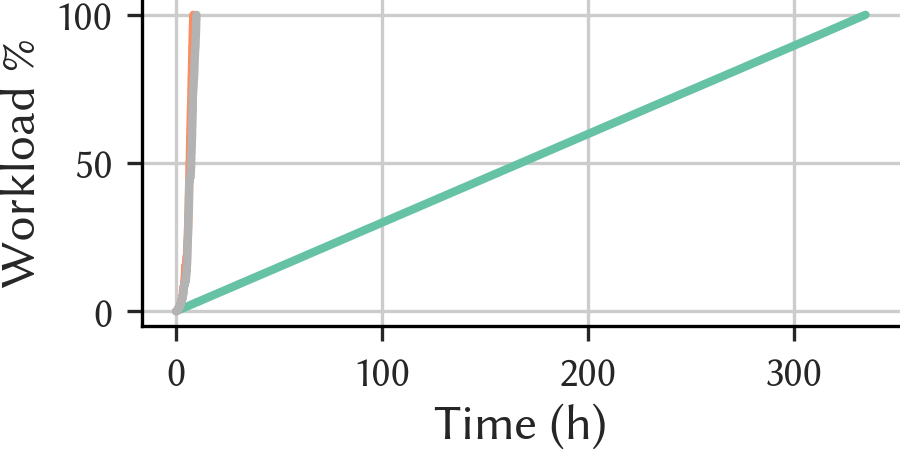

tpch_sf_100 fig_11d


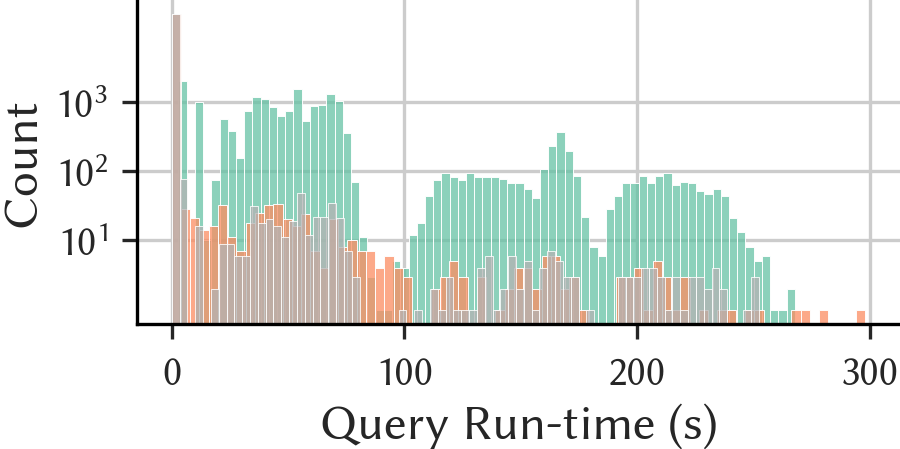

dsb_sf_10 fig_11b


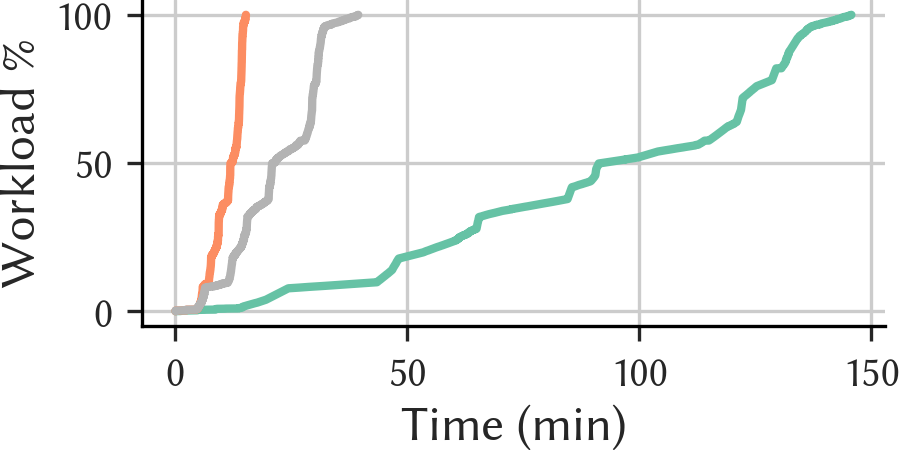

dsb_sf_10 fig_11e


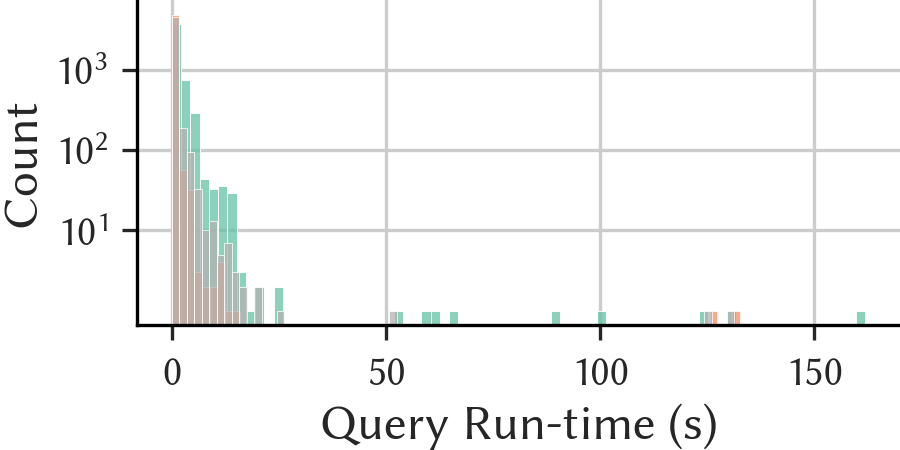

job_sf_none fig_11c


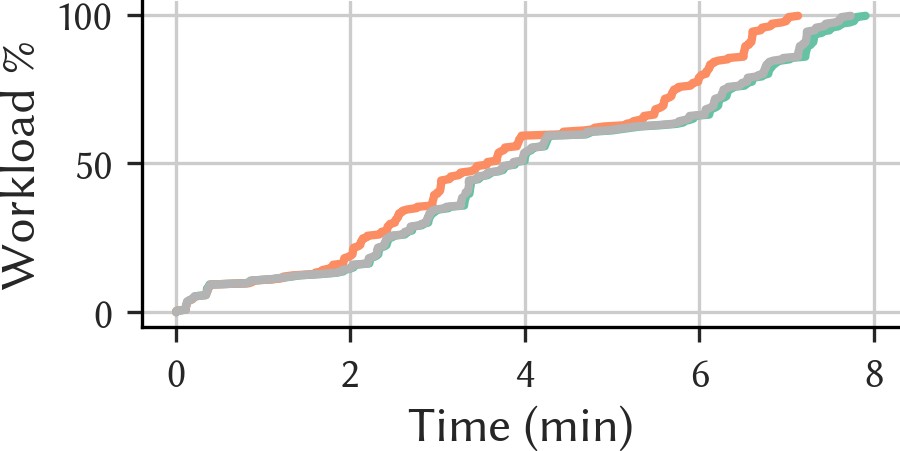

job_sf_none fig_11f


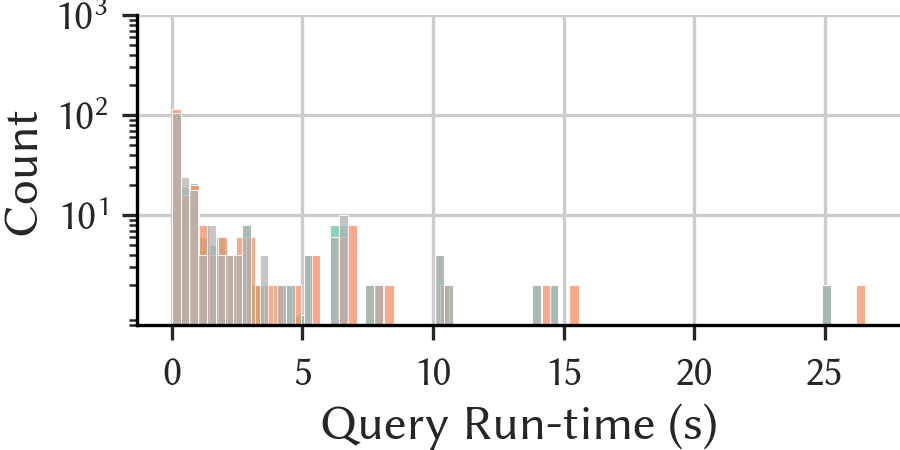

In [13]:
def plot_figure_11():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MA_P_CONFIGS
    names = [rename[c] for c in configs]
    
    expt = [
        "tpch_sf_100",
        "dsb_sf_10",
        "job_sf_none",
    ]
    if SMOKE_TEST:
        expt = [
            "tpch_sf_1",
            "dsb_sf_1",
            "job_sf_none",
        ]
    
    for i, expt_name in enumerate(expt):
        fig_line_name = "fig_11" + chr(ord("a") + i)
        fig_hist_name = "fig_11" + chr(ord("d") + i)
        
        rqs_df = pd.read_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        if "dsb" in expt_name:
            rqs_df["Query"] = rqs_df.Query.astype(str)
            rqs_df["Qsort1"] = rqs_df.Query.str.split("-").apply(lambda x: x[0]).astype(str)
            rqs_df["Qsort2"] = rqs_df.Query.str.split("-").apply(lambda x: x[1]).astype(int)
            rqs_df["Qsort3"] = rqs_df.Query.str.split("-").apply(lambda x: x[2]).astype(int)
            rqs_df = rqs_df[rqs_df.Seed == 15721]
            rqs_df = rqs_df.sort_values(["Seed", "Qsort1", "Qsort2", "Qsort3"])
            rqs_df["fp"] = rqs_df.apply(lambda row: ARTIFACT_ROOT / f"experiment/{rename_inverse['MA']}/dsb/sf_10/default/{row.Seed}/{row.Qsort1}-{row.Qsort2}-{row.Qsort3}.res", axis=1)
            rqs_df["MAd"] = rqs_df["fp"].apply(macro_accelerated)
        elif "tpch" in expt_name:
            rqs_df["Qnum1"] = rqs_df.Query.str.split("-").apply(lambda x: x[0]).astype(int)
            rqs_df["Qnum2"] = rqs_df.Query.str.split("-").apply(lambda x: x[1]).astype(int)
            rqs_df = rqs_df.sort_values(["Seed", "Qnum1", "Qnum2"])
            rqs_df["fp"] = rqs_df.apply(lambda row: ARTIFACT_ROOT / f"experiment/{rename_inverse['MA']}/tpch/sf_100/{row.Seed}/{row.Qnum1}-{row.Qnum2}.res", axis=1)
            rqs_df["MAd"] = rqs_df["fp"].apply(macro_accelerated)
        else:
            assert "job" in expt_name
            rqs_df["Qsort1"] = rqs_df.Query.str.split("-").apply(lambda x: x[0]).astype(str)
            rqs_df["Qsort2"] = rqs_df.Query.str.split("-").apply(lambda x: x[1]).astype(int)
            rqs_df = rqs_df.sort_values(["Seed", "Qsort1", "Qsort2"])
            rqs_df["fp"] = rqs_df.apply(lambda row: ARTIFACT_ROOT / f"experiment/{rename_inverse['MA']}/tpch/sf_100/{row.Seed}/{row.Qsort1}-{row.Qsort2}.res", axis=1)
            rqs_df["MAd"] = rqs_df["fp"].apply(macro_accelerated)
        rqs_df = rqs_df.reset_index(drop=True)
        rqs_df = rqs_df[["Query", "Seed", "MAd", "default", rename_inverse["MA"], rename_inverse["MA.P"]]]
        rqs_df = rqs_df[~rqs_df.isin([300000]).any(axis=1)]
        rqs_df = rqs_df.reset_index(drop=True)

        default = rqs_df.default.cumsum() / 1e3
        bytejack_mat = rqs_df[rename_inverse["MA"]].cumsum() / 1e3
        bytejack_map = rqs_df[rename_inverse["MA.P"]].cumsum() / 1e3

        if "tpch" in expt_name:
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.9))
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=default.values / (60 * 60), name="Original")
            s.plot(ax=ax, color=colors[rename_inverse["Orig"]])
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=bytejack_mat.values / (60 * 60), name="MA")
            s.plot(ax=ax, color=colors[rename_inverse["MA"]])
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=bytejack_map.values / (60 * 60), name="MA.P")
            s.plot(ax=ax, color=colors[rename_inverse["MA.P"]])
            ax.set_xlabel("Time (h)")
            ax.set_ylabel("Workload %")
        else:
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.9))
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=default.values / 60, name="Original")
            s.plot(ax=ax, color=colors[rename_inverse["Orig"]])
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=bytejack_mat.values / 60, name="MA")
            s.plot(ax=ax, color=colors[rename_inverse["MA"]])
            s = pd.Series(rqs_df.index.values / rqs_df.shape[0] * 100, index=bytejack_map.values / 60, name="MA.P")
            s.plot(ax=ax, color=colors[rename_inverse["MA.P"]])
            ax.set_xlabel("Time (min)")
            ax.set_ylabel("Workload %")
        if "fig_11a" in fig_line_name:
            ax.legend()
            h, l = ax.get_legend_handles_labels()
            make_legend(h, l, fig_dir / f"fig_11_legend.pdf", len(names))
            ax.legend_.remove()
        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_line_name}.pdf")
        print(expt_name, fig_line_name)
        plt.show()

        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.9))
        ax = sns.histplot(rqs_df[rename_inverse["Orig"]] / 1e3, bins=75, color=colors[rename_inverse["Orig"]], ax=ax)
        ax = sns.histplot(rqs_df[rename_inverse["MA"]] / 1e3, bins=75, color=colors[rename_inverse["MA"]], ax=ax)
        ax = sns.histplot(rqs_df[rename_inverse["MA.P"]] / 1e3, bins=75, color=colors[rename_inverse["MA.P"]], ax=ax)
        ax.set_xlabel("Query Run-time (s)")
        ax.set_yscale("log")
        ax.set_yticks([10**1, 10**2, 10**3])
        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_hist_name}.pdf")
        print(expt_name, fig_hist_name)
        plt.show()

plot_figure_11()

tpch_sf_100 fig_12a


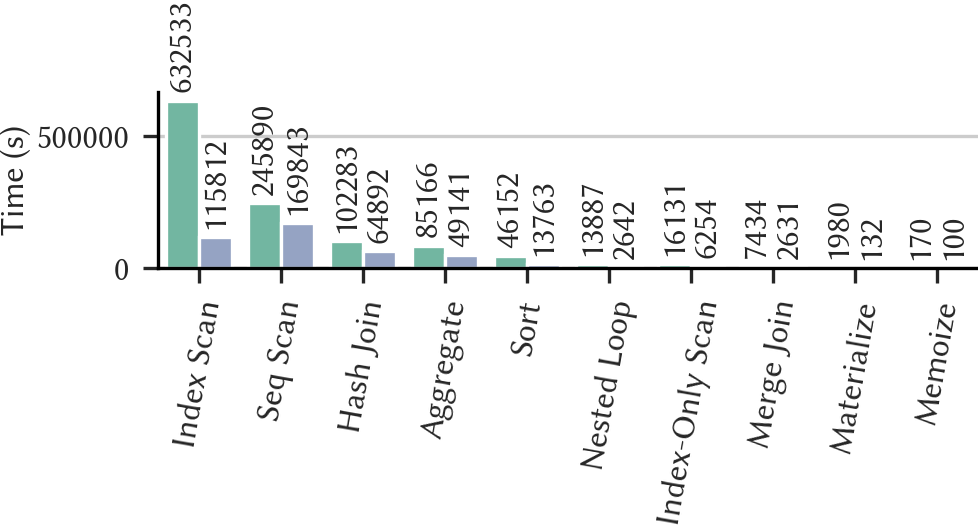

tpch_sf_100 fig_13a


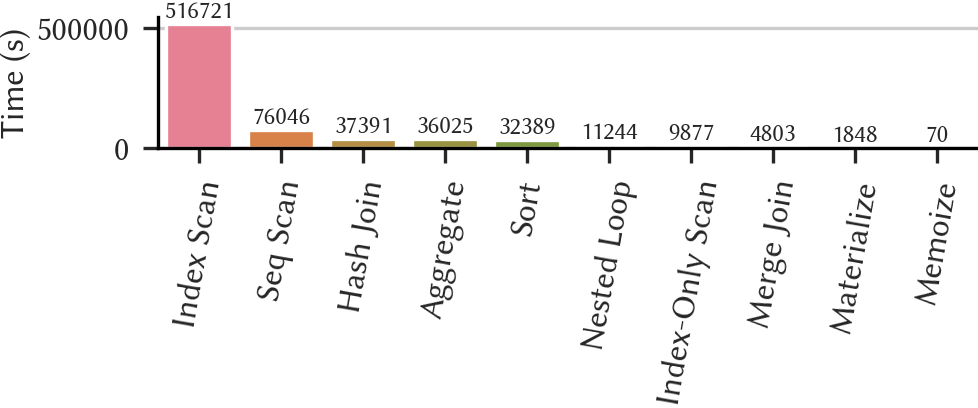

tpch_sf_100 fig_13c


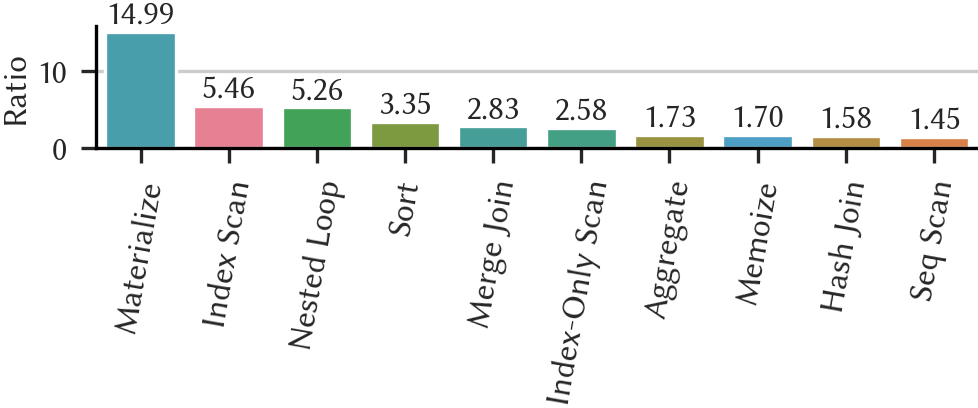

tpch_sf_100 fig_14a


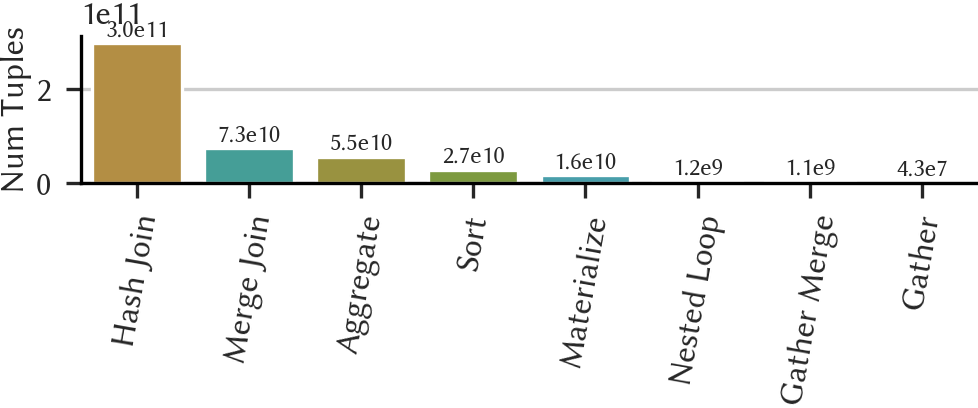

tpch_sf_100 fig_14c


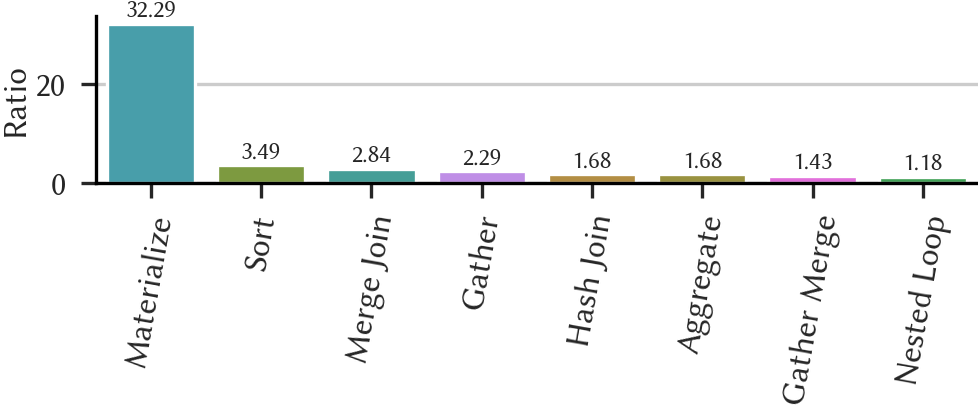

dsb_sf_10 fig_12b


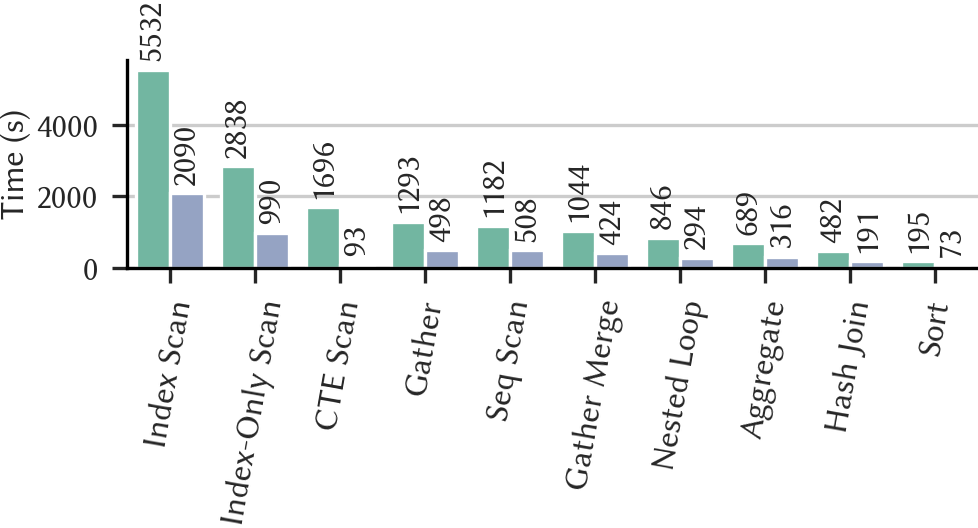

dsb_sf_10 fig_13b


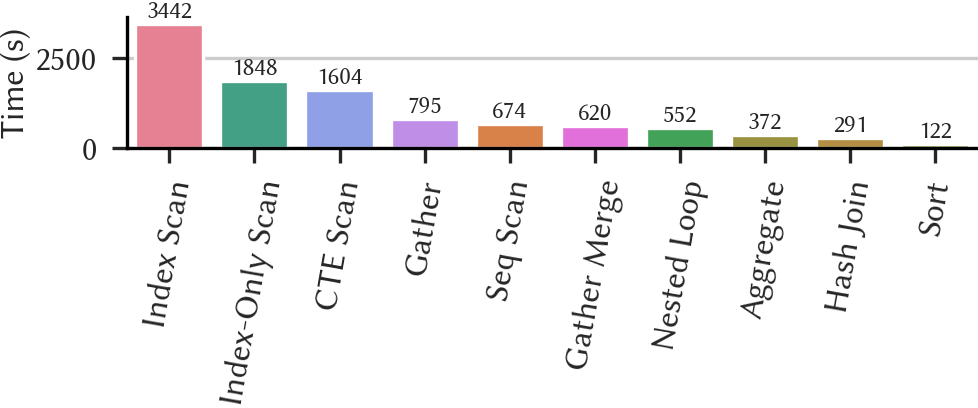

dsb_sf_10 fig_13d


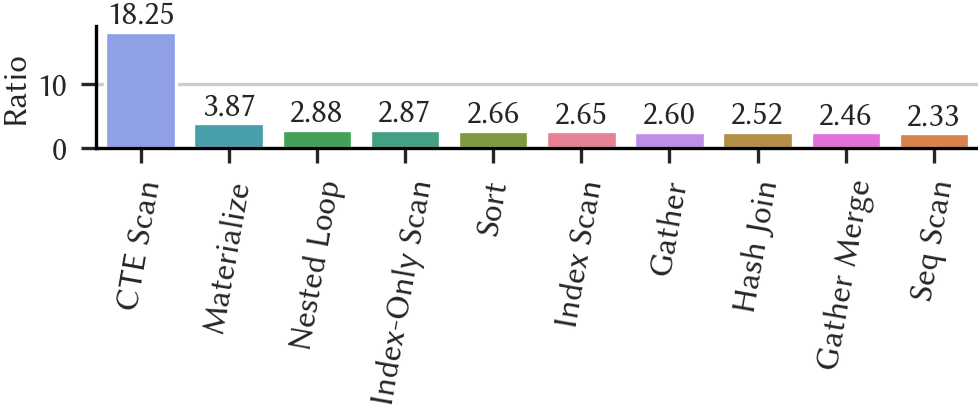

dsb_sf_10 fig_14b


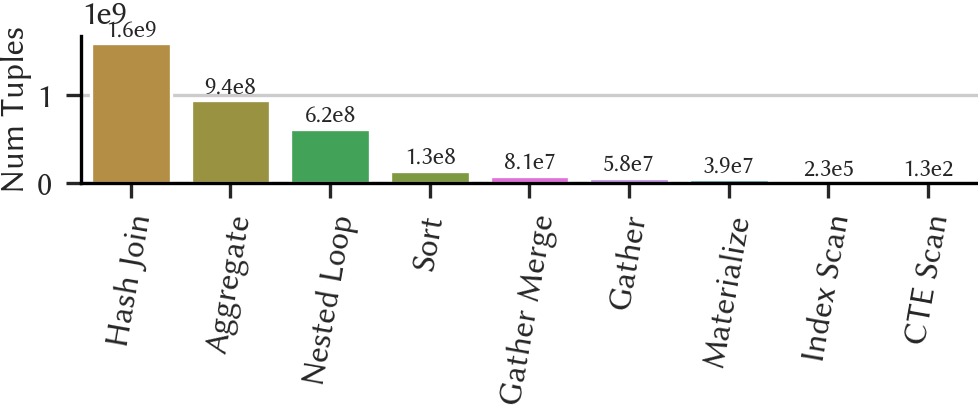

dsb_sf_10 fig_14d


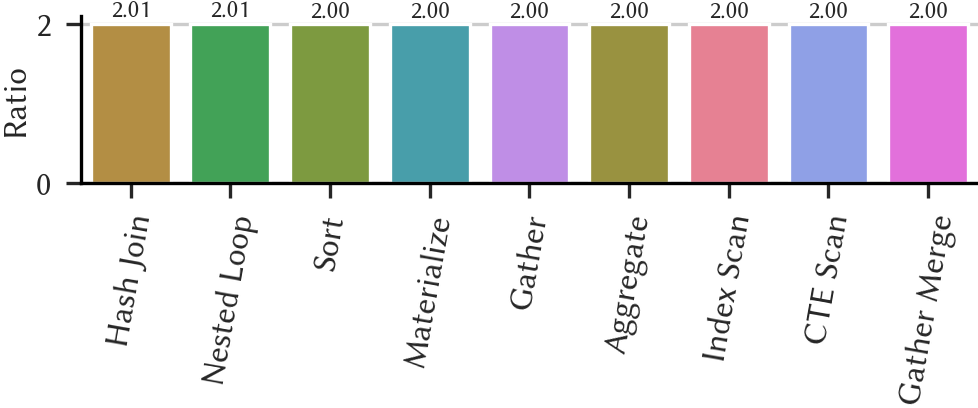

In [14]:
def plot_figure_12_13_14():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = MU_G_CONFIGS
    names = [rename[c] for c in configs]
    
    expt = [
        "tpch_sf_100",
        "dsb_sf_10",
    ]
    if SMOKE_TEST:
        expt = [
            "tpch_sf_1",
            "dsb_sf_1",
        ]
    
    for i, expt_name in enumerate(expt):
        pivotdf_target = "µG"
        renamed_colors = {rename[c]: colors[c] for c in configs}

        df = pd.read_parquet(ARTIFACT_ROOT / f"cache/experiment_{expt_name}.pq")

        # Exhaustive on dataset for tpch_sf_100 and dsb_sf_10.
        node_types = ["Index Scan", "Seq Scan", "Hash Join", "Aggregate", "Sort", "Nested Loop", "Index-Only Scan", "Merge Join", "Materialize", "Memoize", "CTE Scan", "Gather", "Gather Merge", "Bitmap Heap Scan"]
        if SMOKE_TEST:
            node_types += ["Hash", "Bitmap Index Scan", "Limit", "Subquery Scan", "Append", "SetOp", "Result", "Unique", "Incremental Sort"]
        node_colors = {k: v for k, v in zip(node_types, sns.color_palette("husl", len(node_types)))}

        sdf = df[(df[extension_prefix] == False) & (df.DefaultTimeout == False)]
        assert len(sdf) > 0
        sdf = sdf.groupby(["Experiment", "Node Type"]).sum(numeric_only=True)
        sdf = sdf.reset_index()
        sdf["Node Type"] = sdf["Node Type"].apply(lambda x: x if x != "Index Only Scan" else "Index-Only Scan")
        sdf["Experiment"] = sdf["Experiment"].map(rename)
        fsdf = sdf[sdf.Experiment.isin(names)]

        heavy_time = 100
        if SMOKE_TEST:
            heavy_time = 0
        heavy = sdf[(sdf.Experiment == "Orig") & (sdf["Operator Time"] >= heavy_time)]["Node Type"].unique()
        fsdf = fsdf[fsdf["Node Type"].isin(heavy)]
        fsdf = fsdf[fsdf.Experiment.isin(["Orig", pivotdf_target])]
        assert len(fsdf) > 0
        pivotdf = pd.pivot(fsdf, index="Node Type", columns=["Experiment"], values="Operator Time")
        pivotdf["Time (s)"] = pivotdf["Orig"] - pivotdf[pivotdf_target] # diff
        pivotdf["Ratio"] = pivotdf["Orig"] / pivotdf[pivotdf_target]
        pivotdf = pivotdf.reset_index(drop=False).sort_values("Time (s)", ascending=False)
        difforder = pivotdf.head(10)["Node Type"].values
        pivotdf = pivotdf.reset_index(drop=False).sort_values("Ratio", ascending=False)
        ratioorder = pivotdf.head(10)["Node Type"].values

        pivotdf2 = pd.pivot(fsdf, index="Node Type", columns=["Experiment"], values="Actual Input Rows")
        pivotdf2["Num Tuples"] = pivotdf2["Orig"] - pivotdf2[pivotdf_target]
        pivotdf2["Ratio"] = (pivotdf2["Orig"] / pivotdf2[pivotdf_target]).astype(float)
        pivotdf2 = pivotdf2.reset_index(drop=False).sort_values("Num Tuples", ascending=False)
        if not SMOKE_TEST:
            pivotdf2 = pivotdf2[pivotdf2["Num Tuples"] > 0]
        tuporder = pivotdf2.head(10)["Node Type"].values
        pivotdf2 = pivotdf2.reset_index(drop=False).sort_values("Ratio", ascending=False)
        tupratioorder = pivotdf2.head(10)["Node Type"].values

        fig_half()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_half[0], 2))
        ax = sns.barplot(data=fsdf, x="Node Type", y="Operator Time", hue="Experiment", hue_order=names, ax=ax, palette=renamed_colors, order=difforder)
        h, l = ax.get_legend_handles_labels()
        make_legend(h, l, fig_dir / f"fig_12_legend.pdf", len(names))
        ax.legend_.remove()
        ax.tick_params(axis="x", rotation=80)
        ax.set_xlabel("")
        ax.set_ylabel("Time (s)")
        ax.tick_params(axis="x", labelsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt="%.0f", padding=2, fontsize=8, rotation=90)
        fig_letter = chr(ord("a") + i)
        fig_name = f"fig_12{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()

        fig_half()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_half[0], 1.6))
        ax = sns.barplot(data=pivotdf, x="Node Type", y="Time (s)", hue="Node Type", legend=False, ax=ax, order=difforder, palette=node_colors)
        ax.tick_params(axis="x", rotation=80)
        ax.set_xlabel("")
        ax.set_ylabel("Time (s)")
        ax.tick_params(axis="x", labelsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt="%.0f", padding=0, fontsize=6, rotation=0)
        fig_letter = chr(ord("a") + i)
        fig_name = f"fig_13{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()

        fig_half()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_half[0], 1.6))
        ax = sns.barplot(data=pivotdf, x="Node Type", y="Ratio", hue="Node Type", legend=False, ax=ax, order=ratioorder, palette=node_colors)
        ax.tick_params(axis="x", rotation=80)
        ax.set_xlabel("")
        ax.set_ylabel("Ratio")
        ax.tick_params(axis="x", labelsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=0, fontsize=8, rotation=0)
        fig_letter = chr(ord("c") + i)
        fig_name = f"fig_13{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()

        fig_half()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_half[0], 1.6))
        ax = sns.barplot(data=pivotdf2, x="Node Type", y="Num Tuples", hue="Node Type", legend=False, ax=ax, order=tuporder, palette=node_colors)
        ax.tick_params(axis="x", rotation=80)
        ax.set_xlabel("")
        ax.set_ylabel("Num Tuples")
        ax.tick_params(axis="x", labelsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: f"{x:.1e}".replace("+0", "").replace("e+", "e"), padding=0, fontsize=6, rotation=0)
        fig_letter = chr(ord("a") + i)
        fig_name = f"fig_14{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()

        fig_half()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_half[0], 1.6))
        ax = sns.barplot(data=pivotdf2, x="Node Type", y="Ratio", hue="Node Type", legend=False, ax=ax, order=tupratioorder, palette=node_colors)
        ax.tick_params(axis="x", rotation=80)
        ax.set_xlabel("")
        ax.set_ylabel("Ratio")
        ax.tick_params(axis="x", labelsize=8)
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=0, fontsize=6, rotation=0)
        fig_letter = chr(ord("c") + i)
        fig_name = f"fig_14{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()


plot_figure_12_13_14()

tpch_sf_10 std='2' fig_15a


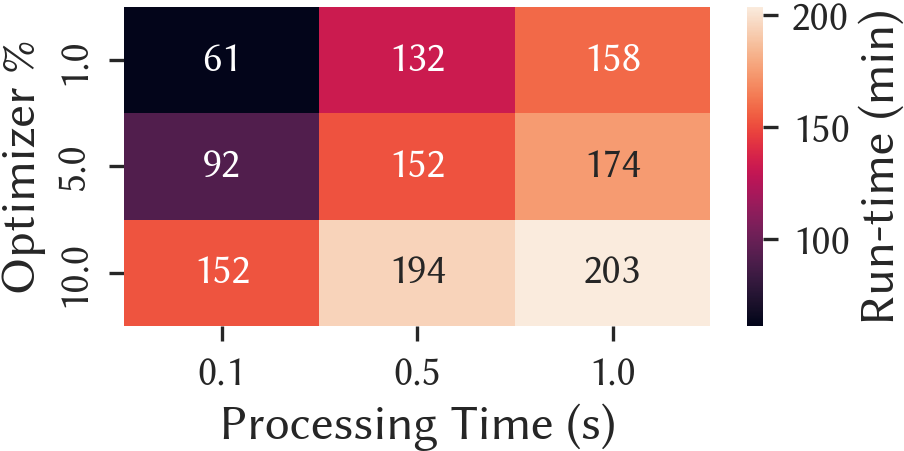

tpch_sf_10 std='2' fig_15b


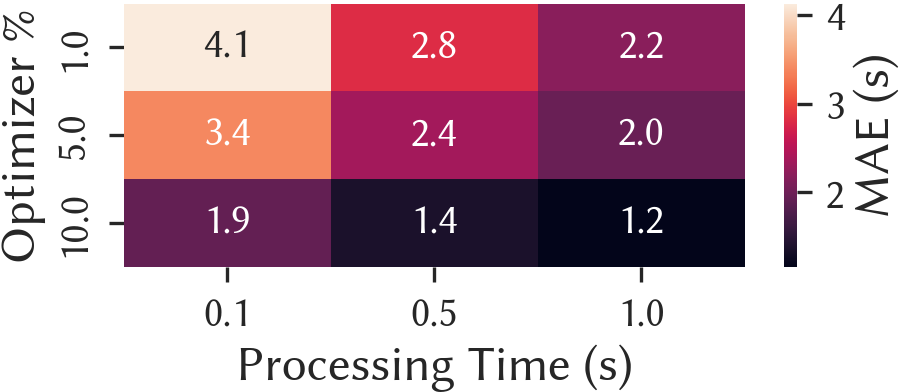

tpch_sf_10 std='3' fig_15c


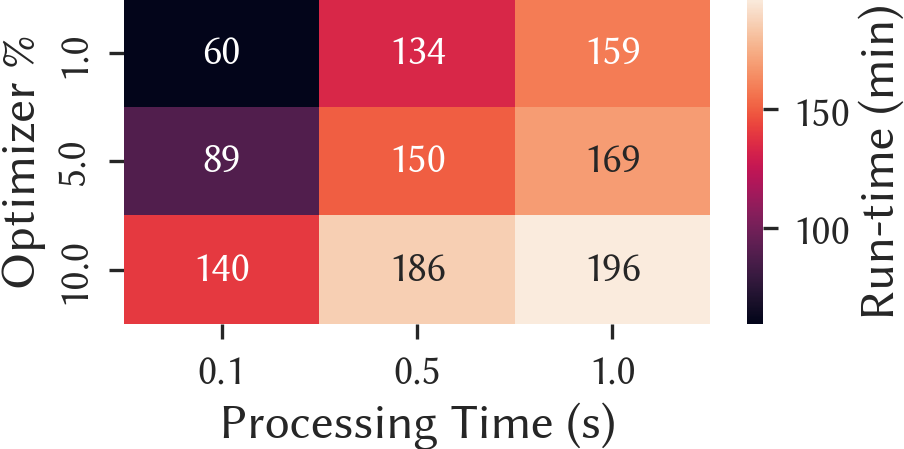

tpch_sf_10 std='3' fig_15d


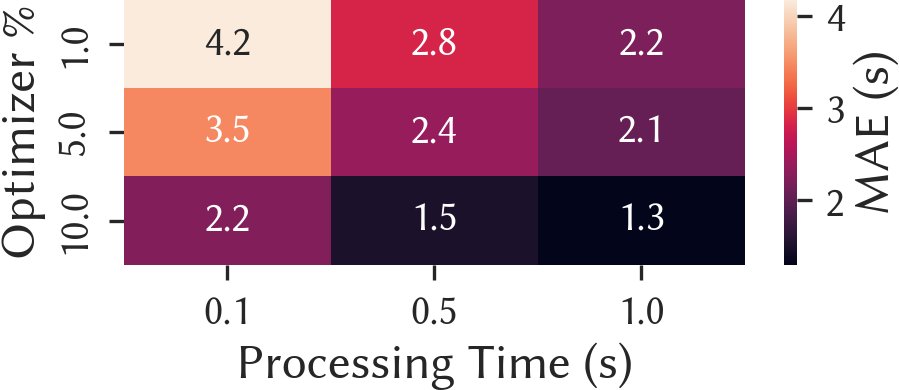

In [15]:
def plot_figure_15():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    expt_name = "tpch_sf_10"
    if SMOKE_TEST:
        expt_name = "tpch_sf_1"
    df = pd.read_csv(ARTIFACT_MUHYP_ROOT / f"model/{expt_name}/summary.csv")
    df = df.set_index("Experiment")
    df["Run-time (s)"] = df["Runtime (s)"]
    df["Run-time (min)"] = df["Run-time (s)"] / 60
    
    def get_colname(hypstdev, hypopt, hyptime):
        return f"{rename_inverse['µG']}_muhypopt_{hypopt}_muhyptime_{hyptime}_muhypstdev_{hypstdev}"
    
    stdevs = ["2", "3"]
    opts = ["0.01", "0.05", "0.1"]
    times = ["100000.0", "500000.0", "1000000.0"]
    
    data = []
    for hypstdev in stdevs:
        for hypopt in opts:
            for hyptime in times:
                datum = df.loc[get_colname(hypstdev, hypopt, hyptime)]
                data.append((float(hypstdev), float(hypopt), float(hyptime), datum["Run-time (min)"], datum["MAE (s)"]))
    data = pd.DataFrame(data, columns=["hypstd", "hypopt", "hyptime", "Run-time (min)", "MAE (s)"])
    data = data.sort_values(["hypstd", "hypopt", "hyptime"])
    data["Optimizer %"] = data["hypopt"] * 100
    data["Processing Time (s)"] = data["hyptime"] / (1e6)
    
    for i, std in enumerate(stdevs):
        sdf = data[data["hypstd"] == float(std)].copy()
        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.9))
        ax = sns.heatmap(sdf.pivot(index="Optimizer %", columns="Processing Time (s)", values="Run-time (min)"), annot=True, fmt=".0f", cbar_kws={"label": "Run-time (min)"}, ax=ax)
        plt.tight_layout()
        fig_letter = chr(ord("a") + 2*i)
        fig_name = f"fig_15{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, f"{std=}", fig_name)
        plt.show()
        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.8))
        ax = sns.heatmap(sdf.pivot(index="Optimizer %", columns="Processing Time (s)", values="MAE (s)"), annot=True, fmt=".1f", cbar_kws={"label": "MAE (s)"}, ax=ax)
        plt.tight_layout()
        fig_letter = chr(ord("b") + 2*i)
        fig_name = f"fig_15{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, f"{std=}", fig_name)
        plt.show()
    
    
plot_figure_15()

tpch_sf_100
Run-time (ms):  [1929170683.861, 1569743787.922, 925090793.463, 304486847.245]
Mean default run-time (ms):  87697.54904359487
std default run-time (ms):  89268.93718612051
Median default run-time (ms):  55132.1485
tpch_sf_100 names and runtimes
['Orig', 'Automatic', 'Manual', 'All-10']
[1929170.683861, 1569743.787922, 925090.7934630001, 304486.847245]
Orig  speedup (x): 1.0
Automatic  speedup (x): 1.228971695065475
Manual  speedup (x): 2.0853852373120163
All-10  speedup (x): 6.335809580335424


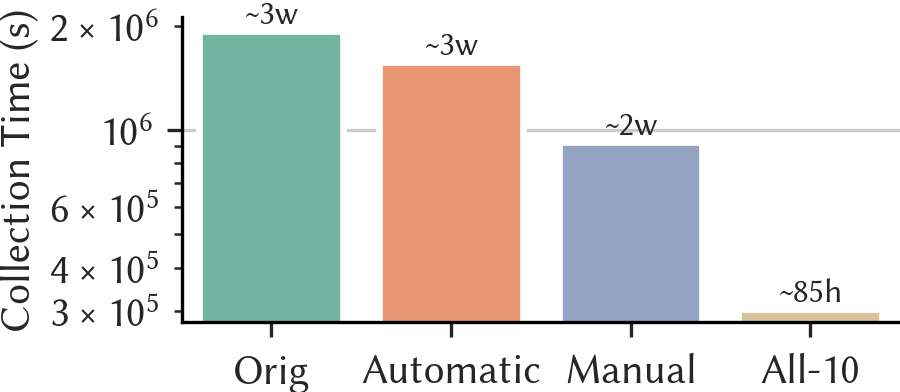

In [16]:
def plot_figure_16a():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = SAMPLING_BASELINE_CONFIGS
    palette = [colors[c] for c in configs]
    names = [rename[c] for c in configs]
    xticklabels = [str(x) for x in names]

    fig_expt = [
        ("fig_16a", "tpch_sf_100"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("fig_16a", "tpch_sf_1"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        rqs_df = read_query_seed_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        runtimes_ms = [rqs_df[c].sum() for c in configs]
        runtimes_readable = [prettify_time(x/1000) for x in runtimes_ms]

        print("Run-time (ms): ", runtimes_ms)
        print("Mean default run-time (ms): ", rqs_df["default"].mean())
        print("std default run-time (ms): ", rqs_df["default"].std())
        print("Median default run-time (ms): ", rqs_df["default"].median())

        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.8))
        plt.rcParams["xtick.labelsize"] = font_mini - 1
        runtimes_s = [x / 1000 for x in runtimes_ms]
        print(f"{expt_name} names and runtimes")
        print(names)
        print(runtimes_s)
        for name, runtime in zip(names, runtimes_s):
            print(name, " speedup (x):", runtimes_s[0] / runtime)
        ax = sns.barplot(x=names, y=runtimes_s, hue=names, palette=palette, dodge=False, ax=ax)
        runtimes_labels = [f"~{b}" for a, b in zip(runtimes_s, runtimes_readable)]
        for container, label in zip(ax.containers, runtimes_labels):
            ax.bar_label(container, fmt=label, padding=0, fontsize=font_mini - 1)
        ax.set_yscale("log")
        ax.set_ylabel("Collection Time (s)", fontsize=font_tiny - 1)

        patches = []
        patches_labels = []
        for c in configs:
            label = rename[c]
            if label == "MA":
                label = "MA (Macro)"
            elif label == "µG":
                label = "µG (Micro, Gate)"
            elif label == "µS":
                label = "µG (Micro, Sampler)"
            patch = mpl.patches.Patch(color=colors[c], label=label)
            patches.append(patch)
            patches_labels.append(label)

        if fig_name == "fig_16a":
            figLegend = plt.figure()
            plt.figlegend(patches, patches_labels, loc="center", ncols=len(patches_labels))
            figLegend.savefig(fig_dir / f"fig_16_legend.pdf")
            plt.close(figLegend)

        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()
    
plot_figure_16a()

tpch_sf_100


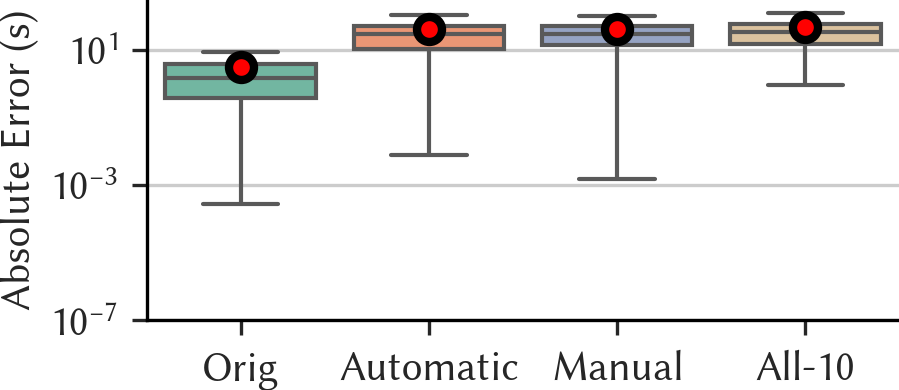

In [17]:
def plot_figure_16b():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = SAMPLING_BASELINE_CONFIGS
    palette = [colors[c] for c in configs]
    names = [rename[c] for c in configs]
    xticklabels = [str(x) for x in names]
    
    fig_expt = [
        ("fig_16b", "tpch_sf_100"),
    ]
    if SMOKE_TEST:
        fig_expt = [
            ("fig_16b", "tpch_sf_1"),
        ]
    
    for fig_name, expt_name in fig_expt:
        print(expt_name)
        eqs_df = pd.read_csv(MODEL_ROOT / f"{expt_name}/error_query_seed.csv")

        fig_quarter()
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1]*0.8))
        plt.rcParams["xtick.labelsize"] = font_mini - 1
        ax = sns.boxplot(eqs_df[configs], showfliers=False, palette=palette, linewidth=0.5, showmeans=True, ax=ax)
        ax.set_yscale("log")
        if expt_name == "dsb_sf_1" or expt_name == "dsb_sf_10":
            ax.set_ylim(bottom=10**-10, top=300)
        else:
            ax.set_ylim(bottom=10**-7, top=300)
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(xticklabels)
        ax.set_ylabel("Absolute Error (s)", fontsize=font_tiny - 1)
        plt.tight_layout()
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        plt.show()
    
plot_figure_16b()

tpch_sf_100 fig_17a


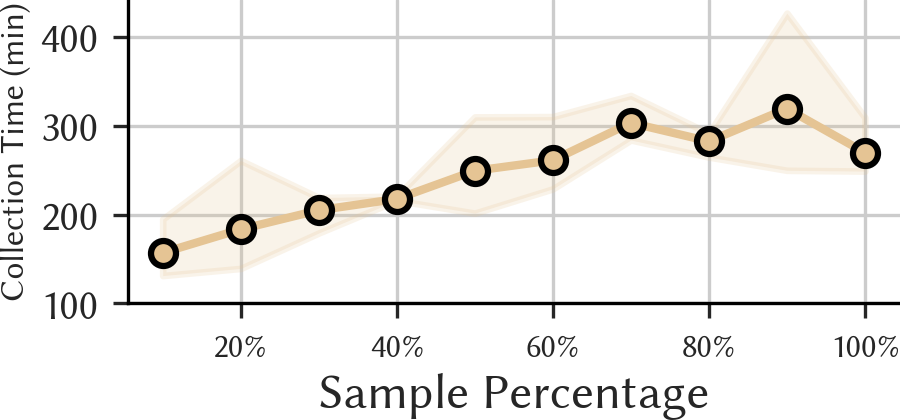

tpch_sf_100 fig_17d


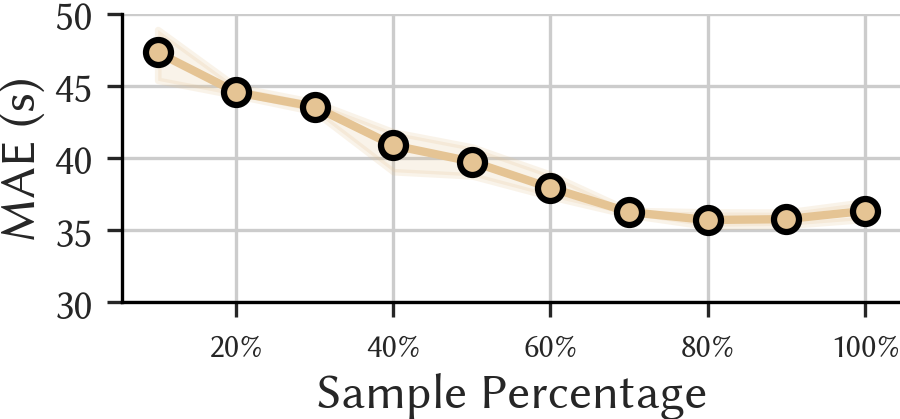

dsb_sf_10 fig_17b


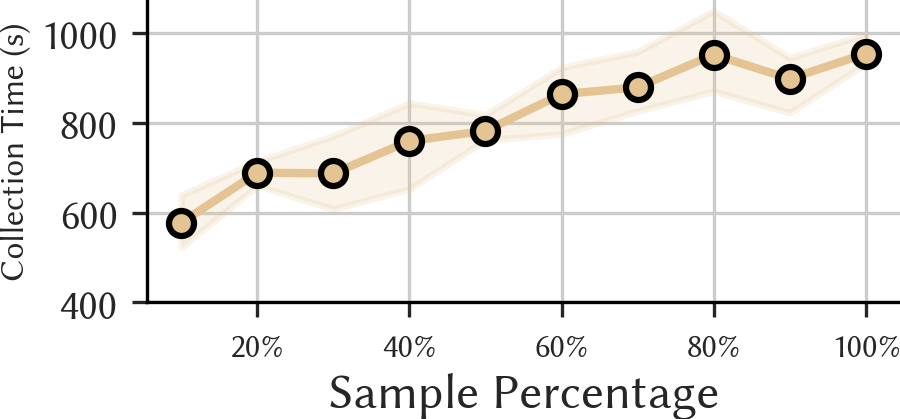

dsb_sf_10 fig_17e


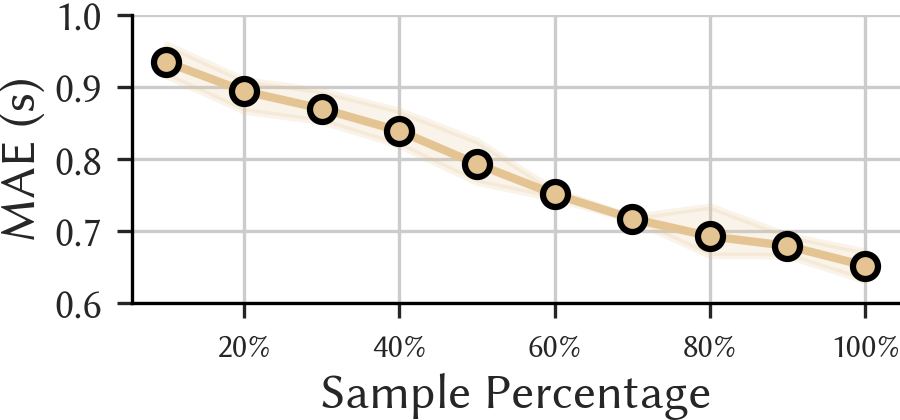

job_sf_none fig_17c


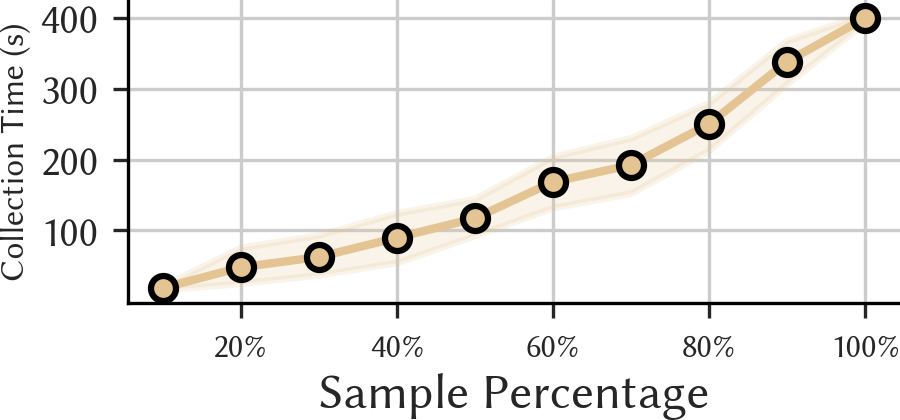

job_sf_none fig_17f


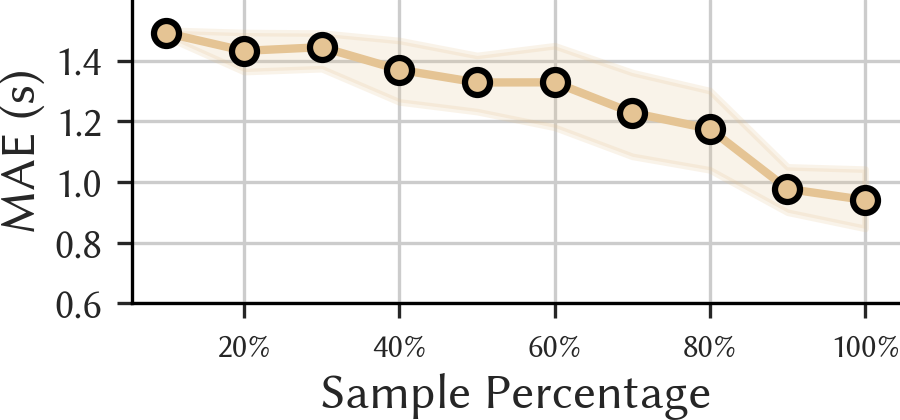

In [18]:
def plot_figure_17():
    fig_dir = PLOT_ROOT
    fig_dir.mkdir(exist_ok=True, parents=True)

    configs = SAMPLING_BASELINE_CONFIGS
    palette = [colors[c] for c in configs]
    names = [rename[c] for c in configs]
    xticklabels = [str(x) for x in names]

    expt = [
        "tpch_sf_100",
        "dsb_sf_10",
        "job_sf_none",
    ]
    if SMOKE_TEST:
        expt = [
            "tpch_sf_1",
            "dsb_sf_1",
            "job_sf_none",
        ]

    for i, expt_name in enumerate(expt):
        if "job" in expt_name:
            seeds = [str(x) for x in range(15721, 15730 + 1)]
        else:
            seeds = [str(x) for x in range(15721, 15723 + 1)]
        configs = generate_sampling_rate_configs(seeds)

        df = pd.read_csv(MODEL_ROOT / f"{expt_name}/runtime_query_seed.csv")
        df = df[configs]
        df = df[~df.isin([300000]).any(axis=1)]
        df = df[configs].sum()

        if "job" in expt_name:
            df.index = list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10))
        else:
            df.index = list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10))

        df = df.to_frame(name="Run-time (ms)")
        df["Collection Time (s)"] = df["Run-time (ms)"] / 1000
        df["Collection Time (min)"] = df["Run-time (ms)"] / (1000 * 60)
        runtime_target = "Collection Time (min)" if "tpch" in expt_name else "Collection Time (s)"
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1] * 0.85))
        ax = sns.lineplot(x=df.index, y=df[runtime_target], color=colors[rename_inverse["All-10"]], marker="o", markeredgecolor="black", ax=ax)
        ax.xaxis.set_major_formatter(PercentFormatter())
        ax.set_xlabel("Sample Percentage")
        ax.set_ylabel(ax.get_ylabel(), fontsize=font_mini - 1)

        if expt_name == "tpch_sf_100":
            ax.set_yticks([100, 200, 300, 400])
        elif expt_name == "dsb_sf_10":
            ax.set_yticks([400, 600, 800, 1000])
        elif expt_name == "job_sf_none":
            ax.set_yticks([100, 200, 300, 400])

        plt.tight_layout()
        fig_letter = chr(ord("a") + i)
        fig_name = f"fig_17{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()

        df = pd.read_csv(MODEL_ROOT / f"{expt_name}/summary.csv")
        df = df.set_index("Experiment").T
        df = df[configs].T

        if "job" in expt_name:
            df.index = list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10))
        else:
            df.index = list(range(10,101,10)) + list(range(10,101,10)) + list(range(10,101,10))

        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(figsize_quarter[0], figsize_quarter[1] * 0.85))
        ax = sns.lineplot(x=df.index, y=df["MAE (s)"], color=colors[rename_inverse["All-10"]], marker="o", markeredgecolor="black")
        ax.set_xticks([20, 40, 60, 80, 100])
        ax.set_yticks(ax.get_yticks())
        ax.set_xticklabels([x.get_text() + "%" for x in ax.get_xticklabels()])
        ax.set_xlabel("Sample Percentage")

        if expt_name == "tpch_sf_100":
            ax.set_yticks([30, 35, 40, 45, 50])
        elif expt_name == "dsb_sf_10":
            ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
        elif expt_name == "job_sf_none":
            ax.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4])

        plt.tight_layout()
        fig_letter = chr(ord("d") + i)
        fig_name = f"fig_17{fig_letter}"
        plt.savefig(fig_dir / f"{fig_name}.pdf")
        print(expt_name, fig_name)
        plt.show()
    
plot_figure_17()